# BASIC PROJECT TO GET E

In [2]:
import importlib
import base_project as bp

## 1.1

### 1.1.1 *Download a pre-trained modern ConvNet such as: ResNet18, ResNet34,...*

In [3]:
import torchvision.models as models

# download pretrained resnet34
# **THIS ONLY DOWNLOADS THE FIRST TIME IT RUNS, THEN GETS CACHED
model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

# validate model
print(model)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### 1.1.2 *Download the dataset*

Heads up the file is pretty big so I wasn't able to add it to the git repo, but theres directions in the assignment for where to get the data, and I documented how this code expects your local directory to look in the readme.

In [4]:
# extract data
import tarfile

for fname in ['images.tar.gz', 'annotations.tar.gz']:
    with tarfile.open(f'./dataset/oxford-iiit-pet/{fname}') as tar:
        tar.extractall('./dataset/oxford-iiit-pet/')


### 1.1.3 *sanity check*

#### load in data

In [5]:
import base_project as bp

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # normalization values for ImageNet (ResNet)
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std  = [0.229, 0.224, 0.225]
    )
])

train_data = datasets.OxfordIIITPet(root='./dataset', split='trainval',
                                     download=False, transform=transform)
test_data  = datasets.OxfordIIITPet(root='./dataset', split='test',
                                     download=False, transform=transform)

# convert labels to binary (dog=0, cat=1)
train_dataset = bp.BinaryPetDataset(train_data)
test_dataset = bp.BinaryPetDataset(test_data)

# set dataloader wrappers
train_loader = DataLoader(train_dataset,
                          batch_size=32, 
                          shuffle=True,
                          num_workers=2)
test_loader = DataLoader(test_dataset,
                          batch_size=32, 
                          shuffle=False, 
                          num_workers=2)


In [6]:
import torch
import torch.nn as nn

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# freeze all layers (for sanity check)
for param in model.parameters():
    param.requires_grad = False

# unfreeze layer 4 and fc 
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

# modify network for binary classification
model.fc = nn.Linear(512, 1)
model = model.to(device)

# init optimizer and loss function
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()


#### actually run sanity check

In [ ]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_accuracy = bp.train_epoch_binary(model, train_loader, optimizer, criterion, device)
    test_loss, test_accuracy = bp.train_epoch_binary(model, test_loader, optimizer, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train loss: {train_loss:.4f}, accuracy: {train_accuracy:.4f} | "
          f"Test loss: {test_loss:.4f}, accuracy: {test_accuracy:.4f}")


Epoch 1/5 | Train loss: 0.0624, accuracy: 0.9802 | Test loss: 0.6892, accuracy: 0.6743
Epoch 2/5 | Train loss: 0.0525, accuracy: 0.9935 | Test loss: 0.3453, accuracy: 0.8915
Epoch 3/5 | Train loss: 0.0374, accuracy: 0.9976 | Test loss: 0.1660, accuracy: 0.9586
Epoch 4/5 | Train loss: 0.0230, accuracy: 0.9978 | Test loss: 0.0743, accuracy: 0.9932
Epoch 5/5 | Train loss: 0.0093, accuracy: 0.9997 | Test loss: 0.0367, accuracy: 0.9995


### 1.1.4 *multi-class linear probing*

In [7]:
train_loader = DataLoader(train_data,
                          batch_size=32, 
                          shuffle=True,
                          num_workers=2)
test_loader = DataLoader(test_data,
                          batch_size=32, 
                          shuffle=False, 
                          num_workers=2)


model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

# freeze model
for param in model.parameters():
    param.requires_grad = False

# only train on new head (linear probing)
model.fc = nn.Linear(512, 37)
model = model.to(device)

optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
# change loss function to standard cross entropy loss for multi-class
criterion = nn.CrossEntropyLoss()


In [ ]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = bp.train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss,  test_acc  = bp.evaluate_epoch(model, test_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
          f"Test loss: {test_loss:.4f}, acc: {test_acc:.4f}")


Epoch 1/5 | Train loss: 1.8210, acc: 0.6041 | Test loss: 0.8256, acc: 0.8179
Epoch 2/5 | Train loss: 0.6134, acc: 0.8734 | Test loss: 0.5291, acc: 0.8659
Epoch 3/5 | Train loss: 0.4246, acc: 0.9016 | Test loss: 0.4502, acc: 0.8708
Epoch 4/5 | Train loss: 0.3380, acc: 0.9242 | Test loss: 0.4102, acc: 0.8823
Epoch 5/5 | Train loss: 0.2721, acc: 0.9391 | Test loss: 0.3903, acc: 0.8793


## 1.2 Fine-tuning the network

### 1.2.1 Strategy 1: Fine-tune last l layers simultaneously

In [ ]:
NUM_EPOCHS = 20
strategy1_results = {}

for l in range(1, 5):
    # bp.set_seed(42)
    model = bp.get_model_finetune(num_classes=37)
    bp.unfreeze_layers(model, l)
    model = model.to(device)
    optimizer = bp.get_optimizer(model, l, base_lr=1e-5)
    criterion = nn.CrossEntropyLoss()

    print(f"\n------ l={l} | unfreezing: fc + {bp.RESNET34_LAYER_GROUPS[:l]} ------")
    epoch_accs = []

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = bp.train_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc   = bp.evaluate_epoch(model, test_loader, criterion, device)
        epoch_accs.append(test_acc)

        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
              f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
              f"Test loss: {test_loss:.4f}, acc: {test_acc:.4f}")

    strategy1_results[l] = max(epoch_accs)
    print(f"Best test acc for l={l}: {strategy1_results[l]:.4f}")

print("\n------ Strategy 1 Summary ------")
for l, acc in strategy1_results.items():
    print(f"l={l}: best test acc = {acc:.4f}")



------ l=1 | unfreezing: fc + ['layer4'] ------
Epoch 1/20 | Train loss: 3.1368, acc: 0.1997 | Test loss: 2.3950, acc: 0.5345
Epoch 2/20 | Train loss: 1.9608, acc: 0.7027 | Test loss: 1.5214, acc: 0.8013
Epoch 3/20 | Train loss: 1.2954, acc: 0.8649 | Test loss: 1.0720, acc: 0.8670
Epoch 4/20 | Train loss: 0.9262, acc: 0.9087 | Test loss: 0.8162, acc: 0.8863
Epoch 5/20 | Train loss: 0.6906, acc: 0.9296 | Test loss: 0.6777, acc: 0.8934
Epoch 6/20 | Train loss: 0.5547, acc: 0.9364 | Test loss: 0.5782, acc: 0.8983
Epoch 7/20 | Train loss: 0.4511, acc: 0.9492 | Test loss: 0.5207, acc: 0.9000
Epoch 8/20 | Train loss: 0.3699, acc: 0.9571 | Test loss: 0.4788, acc: 0.9016
Epoch 9/20 | Train loss: 0.3125, acc: 0.9666 | Test loss: 0.4432, acc: 0.9030
Epoch 10/20 | Train loss: 0.2654, acc: 0.9704 | Test loss: 0.4194, acc: 0.9027
Epoch 11/20 | Train loss: 0.2212, acc: 0.9769 | Test loss: 0.4094, acc: 0.9060
Epoch 12/20 | Train loss: 0.1902, acc: 0.9834 | Test loss: 0.3912, acc: 0.9038
Epoch 13/20 

### 1.2.2 Strategy 2: Gradual un-freezing

In [ ]:
EPOCHS_PER_STAGE = 5
BASE_LR = 5e-5
strategy2_best = 0.0
total_epoch = 0

# bp.set_seed(42)
model = bp.get_model_finetune(num_classes=37).to(device)
criterion = nn.CrossEntropyLoss()

print("------ Strategy 2: Gradual Unfreezing ------")

for stage in range(4):
    bp.unfreeze_layers(model, stage + 1)
    optimizer = bp.get_optimizer(model, stage + 1, base_lr=BASE_LR)

    print(f"\n-- Stage {stage+1} | unfrozen: fc + {bp.RESNET34_LAYER_GROUPS[:stage+1]} --")

    for epoch in range(EPOCHS_PER_STAGE):
        total_epoch += 1
        train_loss, train_acc = bp.train_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc   = bp.evaluate_epoch(model, test_loader, criterion, device)
        strategy2_best = max(strategy2_best, test_acc)

        print(f"Epoch {total_epoch}/{4*EPOCHS_PER_STAGE} | "
              f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
              f"Test loss: {test_loss:.4f}, acc: {test_acc:.4f}")

print(f"\nBest test acc (Strategy 2): {strategy2_best:.4f}")


------ Strategy 2: Gradual Unfreezing ------

-- Stage 1 | unfrozen: fc + ['layer4'] --
Epoch 1/20 | Train loss: 1.7497, acc: 0.6492 | Test loss: 0.6986, acc: 0.8705
Epoch 2/20 | Train loss: 0.4779, acc: 0.9272 | Test loss: 0.4459, acc: 0.8921
Epoch 3/20 | Train loss: 0.2305, acc: 0.9701 | Test loss: 0.3804, acc: 0.8983
Epoch 4/20 | Train loss: 0.1200, acc: 0.9905 | Test loss: 0.3649, acc: 0.9005
Epoch 5/20 | Train loss: 0.0675, acc: 0.9981 | Test loss: 0.3477, acc: 0.9054

-- Stage 2 | unfrozen: fc + ['layer4', 'layer3'] --
Epoch 6/20 | Train loss: 0.0508, acc: 0.9943 | Test loss: 0.3484, acc: 0.9027
Epoch 7/20 | Train loss: 0.0284, acc: 0.9976 | Test loss: 0.3612, acc: 0.8997
Epoch 8/20 | Train loss: 0.0160, acc: 0.9986 | Test loss: 0.3417, acc: 0.9041
Epoch 9/20 | Train loss: 0.0104, acc: 0.9989 | Test loss: 0.3442, acc: 0.9038
Epoch 10/20 | Train loss: 0.0077, acc: 0.9997 | Test loss: 0.3592, acc: 0.9024

-- Stage 3 | unfrozen: fc + ['layer4', 'layer3', 'layer2'] --
Epoch 11/20 | T

### Result comparison

In [ ]:
print("\n------ Final Comparison ------")
best_l = max(strategy1_results, key=strategy1_results.get)

print(f"Strategy 1 best (l={best_l}): {strategy1_results[best_l]:.4f}")
print(f"Strategy 2 best:       {strategy2_best:.4f}")



------ Final Comparison ------
Strategy 1 best (l=2): 0.9141
Strategy 2 best:       0.9054


### 1.2.3 Train with best strategy : Fine-tune l (l=2) layers simultaneously

Epoch 1/30 | Train loss: 3.2104, acc: 0.1739 | Test loss: 2.4442, acc: 0.4554
Epoch 2/30 | Train loss: 1.9534, acc: 0.6668 | Test loss: 1.4965, acc: 0.7724
Epoch 3/30 | Train loss: 1.2446, acc: 0.8459 | Test loss: 1.0350, acc: 0.8580
Epoch 4/30 | Train loss: 0.8855, acc: 0.9005 | Test loss: 0.7841, acc: 0.8779
Epoch 5/30 | Train loss: 0.6618, acc: 0.9247 | Test loss: 0.6460, acc: 0.8913
Epoch 6/30 | Train loss: 0.5249, acc: 0.9351 | Test loss: 0.5595, acc: 0.8959
Epoch 7/30 | Train loss: 0.4177, acc: 0.9516 | Test loss: 0.5022, acc: 0.9005
Epoch 8/30 | Train loss: 0.3474, acc: 0.9584 | Test loss: 0.4671, acc: 0.9019
Epoch 9/30 | Train loss: 0.2834, acc: 0.9679 | Test loss: 0.4274, acc: 0.9076
Epoch 10/30 | Train loss: 0.2381, acc: 0.9750 | Test loss: 0.4164, acc: 0.9049
Epoch 11/30 | Train loss: 0.1943, acc: 0.9842 | Test loss: 0.3959, acc: 0.9046
Epoch 12/30 | Train loss: 0.1677, acc: 0.9872 | Test loss: 0.3836, acc: 0.9073
Epoch 13/30 | Train loss: 0.1397, acc: 0.9927 | Test loss: 0.

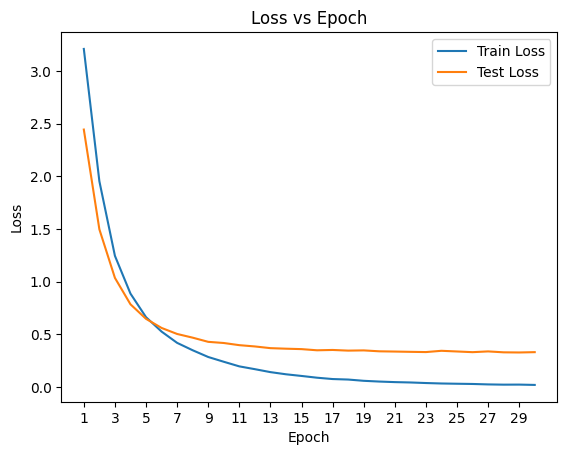

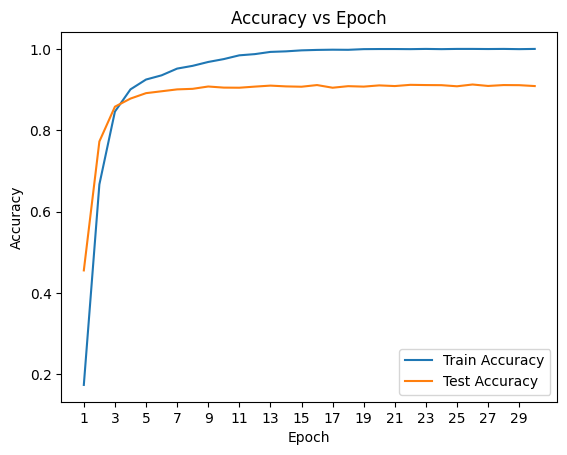

In [ ]:
importlib.reload(bp)
# bp.set_seed(42)
l = 2
num_classes = 37
base_lr = 1e-5
num_epochs = 30

model = bp.get_model_finetune(num_classes=num_classes)
bp.unfreeze_layers(model, l)
model = model.to(device)

optimizer = bp.get_optimizer(model, l, base_lr=base_lr)
criterion = nn.CrossEntropyLoss()

train_losses, test_losses, train_accs, test_accs, best_model, best_acc = bp.train_with_history(
    model, train_loader, test_loader, optimizer, criterion, device, num_epochs=num_epochs
)
model.load_state_dict(best_model)
final_model = model
torch.save(final_model.state_dict(), "resnet34_l2.pth")

print(f"\nBest test acc: {best_acc:.4f}")

bp.plot_training_curves(train_losses, test_losses, train_accs, test_accs)


### Experiments using different fractions of the training set

### Round 1


FRACTION: 100%

-- S1 l=1 | frac=1.0 --
Epoch 1/20 | Train loss: 3.1258, acc: 0.2313 | Test loss: 2.3925, acc: 0.5413
Epoch 2/20 | Train loss: 1.9446, acc: 0.7139 | Test loss: 1.5065, acc: 0.8005
Epoch 3/20 | Train loss: 1.2926, acc: 0.8541 | Test loss: 1.0682, acc: 0.8493
Epoch 4/20 | Train loss: 0.9469, acc: 0.8921 | Test loss: 0.8358, acc: 0.8724
Epoch 5/20 | Train loss: 0.7211, acc: 0.9193 | Test loss: 0.6829, acc: 0.8801
Epoch 6/20 | Train loss: 0.5788, acc: 0.9280 | Test loss: 0.5943, acc: 0.8899
Epoch 7/20 | Train loss: 0.4781, acc: 0.9413 | Test loss: 0.5289, acc: 0.8967
Epoch 8/20 | Train loss: 0.3903, acc: 0.9554 | Test loss: 0.4853, acc: 0.8967
Epoch 9/20 | Train loss: 0.3255, acc: 0.9658 | Test loss: 0.4558, acc: 0.8983
Epoch 10/20 | Train loss: 0.2724, acc: 0.9698 | Test loss: 0.4287, acc: 0.8994
Epoch 11/20 | Train loss: 0.2283, acc: 0.9796 | Test loss: 0.4186, acc: 0.8989
Epoch 12/20 | Train loss: 0.1962, acc: 0.9815 | Test loss: 0.3967, acc: 0.9024
Epoch 13/20 | Train 

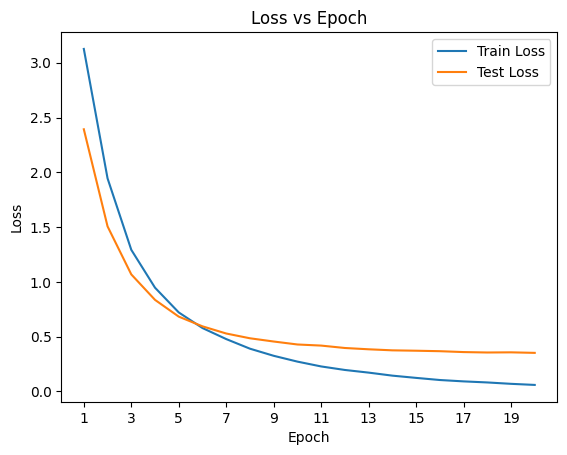

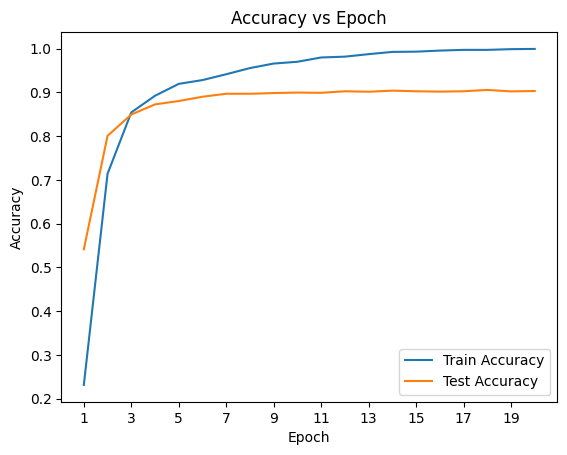


-- S1 l=2 | frac=1.0 --
Epoch 1/20 | Train loss: 3.1255, acc: 0.2462 | Test loss: 2.4147, acc: 0.5236
Epoch 2/20 | Train loss: 1.9278, acc: 0.7128 | Test loss: 1.4929, acc: 0.7877
Epoch 3/20 | Train loss: 1.2445, acc: 0.8712 | Test loss: 1.0279, acc: 0.8545
Epoch 4/20 | Train loss: 0.8806, acc: 0.9038 | Test loss: 0.7891, acc: 0.8705
Epoch 5/20 | Train loss: 0.6720, acc: 0.9193 | Test loss: 0.6456, acc: 0.8844
Epoch 6/20 | Train loss: 0.5261, acc: 0.9353 | Test loss: 0.5626, acc: 0.8929
Epoch 7/20 | Train loss: 0.4270, acc: 0.9459 | Test loss: 0.5050, acc: 0.8967
Epoch 8/20 | Train loss: 0.3544, acc: 0.9579 | Test loss: 0.4629, acc: 0.8967
Epoch 9/20 | Train loss: 0.2931, acc: 0.9641 | Test loss: 0.4359, acc: 0.9011
Epoch 10/20 | Train loss: 0.2441, acc: 0.9747 | Test loss: 0.4111, acc: 0.9032
Epoch 11/20 | Train loss: 0.2063, acc: 0.9818 | Test loss: 0.3945, acc: 0.9041
Epoch 12/20 | Train loss: 0.1712, acc: 0.9875 | Test loss: 0.3835, acc: 0.9065
Epoch 13/20 | Train loss: 0.1473, ac

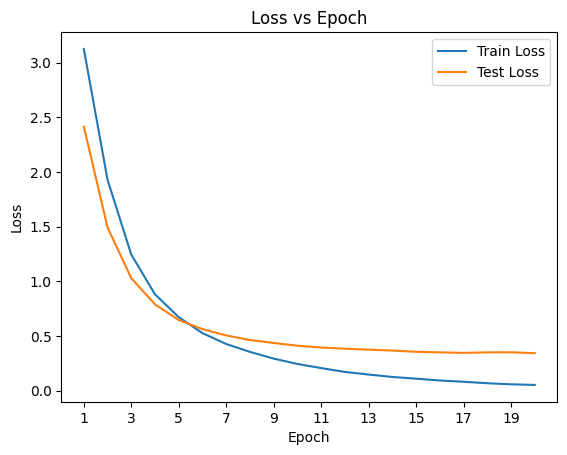

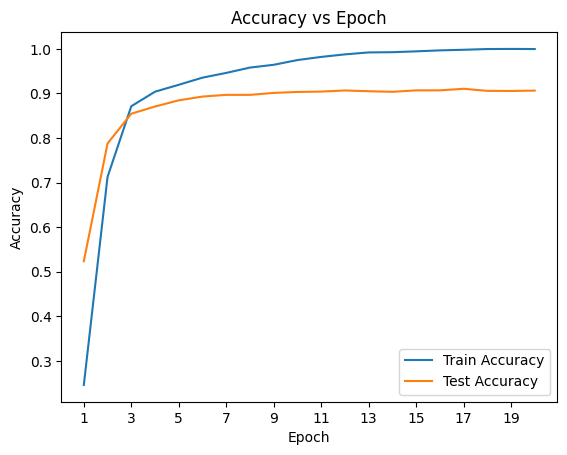


-- S1 l=3 | frac=1.0 --
Epoch 1/20 | Train loss: 3.1309, acc: 0.2209 | Test loss: 2.4063, acc: 0.5443
Epoch 2/20 | Train loss: 1.9429, acc: 0.7223 | Test loss: 1.4996, acc: 0.8087
Epoch 3/20 | Train loss: 1.2563, acc: 0.8649 | Test loss: 1.0198, acc: 0.8621
Epoch 4/20 | Train loss: 0.8888, acc: 0.9084 | Test loss: 0.7790, acc: 0.8833
Epoch 5/20 | Train loss: 0.6674, acc: 0.9264 | Test loss: 0.6390, acc: 0.8877
Epoch 6/20 | Train loss: 0.5260, acc: 0.9356 | Test loss: 0.5516, acc: 0.8978
Epoch 7/20 | Train loss: 0.4265, acc: 0.9473 | Test loss: 0.4947, acc: 0.9013
Epoch 8/20 | Train loss: 0.3466, acc: 0.9568 | Test loss: 0.4558, acc: 0.9022
Epoch 9/20 | Train loss: 0.2875, acc: 0.9709 | Test loss: 0.4251, acc: 0.9057
Epoch 10/20 | Train loss: 0.2338, acc: 0.9791 | Test loss: 0.4031, acc: 0.9041
Epoch 11/20 | Train loss: 0.2034, acc: 0.9818 | Test loss: 0.3810, acc: 0.9092
Epoch 12/20 | Train loss: 0.1699, acc: 0.9894 | Test loss: 0.3749, acc: 0.9087
Epoch 13/20 | Train loss: 0.1428, ac

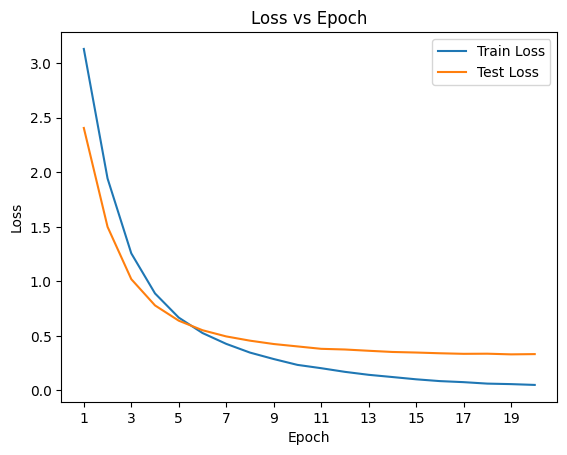

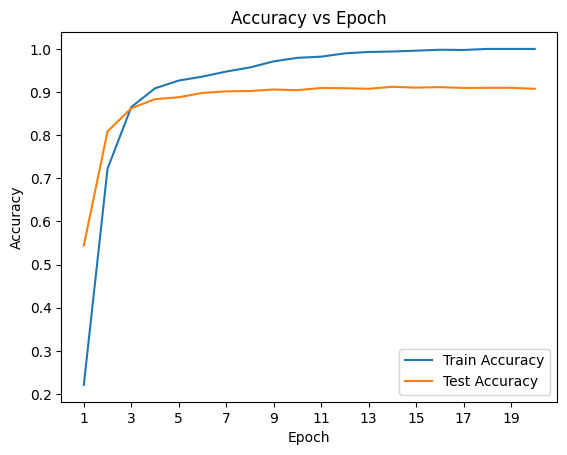


-- S1 l=4 | frac=1.0 --
Epoch 1/20 | Train loss: 3.1713, acc: 0.1753 | Test loss: 2.4262, acc: 0.4587
Epoch 2/20 | Train loss: 1.9662, acc: 0.6693 | Test loss: 1.5026, acc: 0.7825
Epoch 3/20 | Train loss: 1.2767, acc: 0.8451 | Test loss: 1.0421, acc: 0.8539
Epoch 4/20 | Train loss: 0.8989, acc: 0.8997 | Test loss: 0.7982, acc: 0.8801
Epoch 5/20 | Train loss: 0.6636, acc: 0.9177 | Test loss: 0.6450, acc: 0.8918
Epoch 6/20 | Train loss: 0.5175, acc: 0.9399 | Test loss: 0.5616, acc: 0.8967
Epoch 7/20 | Train loss: 0.4260, acc: 0.9508 | Test loss: 0.4935, acc: 0.9035
Epoch 8/20 | Train loss: 0.3482, acc: 0.9630 | Test loss: 0.4514, acc: 0.9024
Epoch 9/20 | Train loss: 0.2778, acc: 0.9707 | Test loss: 0.4262, acc: 0.9081
Epoch 10/20 | Train loss: 0.2304, acc: 0.9766 | Test loss: 0.4009, acc: 0.9076
Epoch 11/20 | Train loss: 0.1981, acc: 0.9818 | Test loss: 0.3840, acc: 0.9062
Epoch 12/20 | Train loss: 0.1696, acc: 0.9853 | Test loss: 0.3753, acc: 0.9084
Epoch 13/20 | Train loss: 0.1373, ac

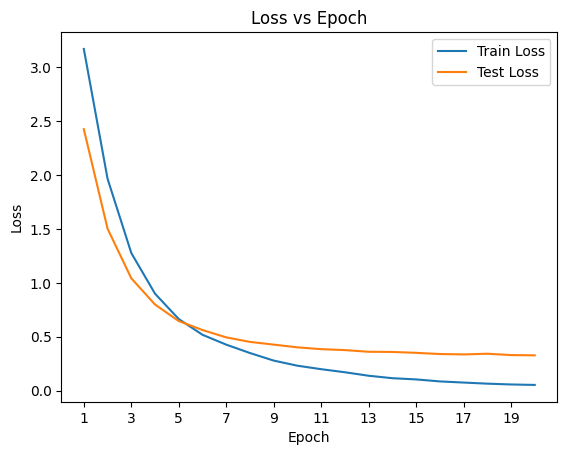

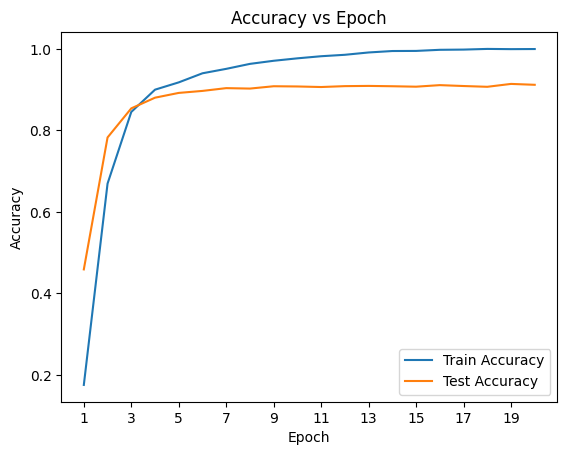


-- S2 stage=1 | frac=1.0 --
Epoch 1/5 | Train loss: 3.2251, acc: 0.1747 | Test loss: 2.5409, acc: 0.4105
Epoch 2/5 | Train loss: 2.0465, acc: 0.6601 | Test loss: 1.6174, acc: 0.7904
Epoch 3/5 | Train loss: 1.3481, acc: 0.8495 | Test loss: 1.1128, acc: 0.8550
Epoch 4/5 | Train loss: 0.9554, acc: 0.8992 | Test loss: 0.8523, acc: 0.8831
Epoch 5/5 | Train loss: 0.7209, acc: 0.9160 | Test loss: 0.7098, acc: 0.8910

-- S2 stage=2 | frac=1.0 --
Epoch 1/5 | Train loss: 0.5624, acc: 0.9332 | Test loss: 0.5611, acc: 0.8962
Epoch 2/5 | Train loss: 0.4124, acc: 0.9508 | Test loss: 0.4925, acc: 0.9027
Epoch 3/5 | Train loss: 0.3274, acc: 0.9592 | Test loss: 0.4475, acc: 0.9011
Epoch 4/5 | Train loss: 0.2578, acc: 0.9715 | Test loss: 0.4117, acc: 0.9073
Epoch 5/5 | Train loss: 0.2064, acc: 0.9829 | Test loss: 0.3899, acc: 0.9043

-- S2 stage=3 | frac=1.0 --
Epoch 1/5 | Train loss: 0.1644, acc: 0.9870 | Test loss: 0.3730, acc: 0.9049
Epoch 2/5 | Train loss: 0.1252, acc: 0.9951 | Test loss: 0.3581, a

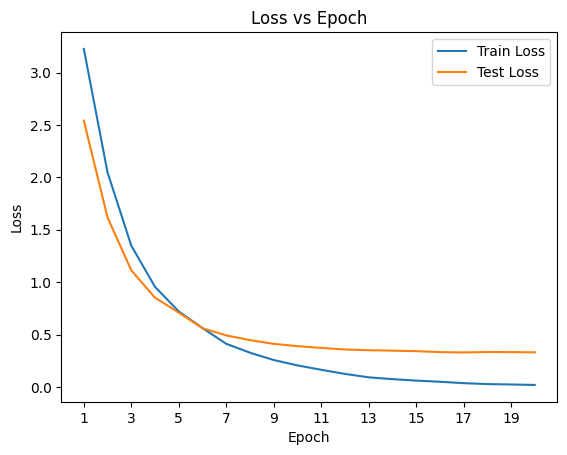

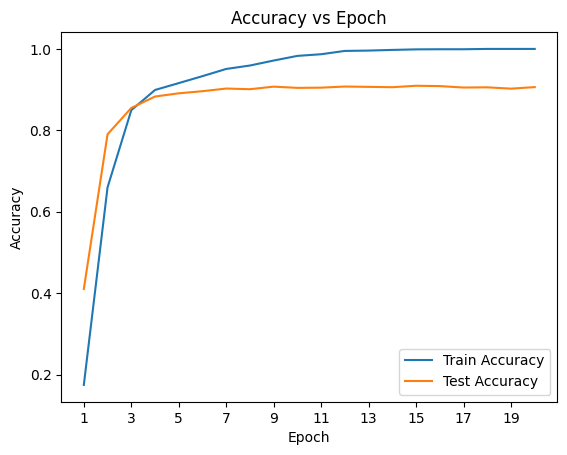


FRACTION: 10%

-- S1 l=1 | frac=0.1 --
Epoch 1/20 | Train loss: 3.7083, acc: 0.0411 | Test loss: 3.6311, acc: 0.0651
Epoch 2/20 | Train loss: 3.4726, acc: 0.0822 | Test loss: 3.4808, acc: 0.0976
Epoch 3/20 | Train loss: 3.2294, acc: 0.1644 | Test loss: 3.3409, acc: 0.1256
Epoch 4/20 | Train loss: 2.9998, acc: 0.2685 | Test loss: 3.2031, acc: 0.1703
Epoch 5/20 | Train loss: 2.8081, acc: 0.3918 | Test loss: 3.0724, acc: 0.2232
Epoch 6/20 | Train loss: 2.6052, acc: 0.5151 | Test loss: 2.9517, acc: 0.2747
Epoch 7/20 | Train loss: 2.4265, acc: 0.5836 | Test loss: 2.8297, acc: 0.3385
Epoch 8/20 | Train loss: 2.2191, acc: 0.6877 | Test loss: 2.7156, acc: 0.3987
Epoch 9/20 | Train loss: 2.0717, acc: 0.7863 | Test loss: 2.6091, acc: 0.4546
Epoch 10/20 | Train loss: 1.9304, acc: 0.8521 | Test loss: 2.5119, acc: 0.4963
Epoch 11/20 | Train loss: 1.7717, acc: 0.8877 | Test loss: 2.4162, acc: 0.5348
Epoch 12/20 | Train loss: 1.6415, acc: 0.9068 | Test loss: 2.3292, acc: 0.5647
Epoch 13/20 | Train l

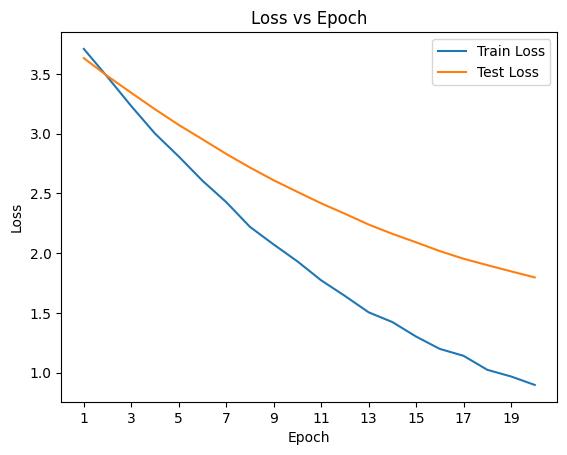

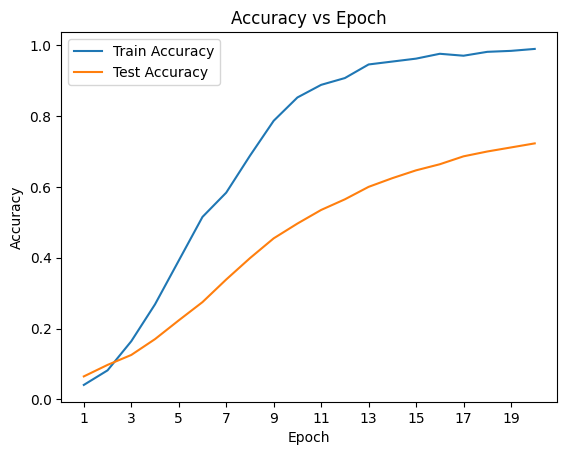


-- S1 l=2 | frac=0.1 --
Epoch 1/20 | Train loss: 3.7898, acc: 0.0164 | Test loss: 3.7061, acc: 0.0286
Epoch 2/20 | Train loss: 3.4767, acc: 0.0603 | Test loss: 3.5418, acc: 0.0507
Epoch 3/20 | Train loss: 3.2218, acc: 0.1370 | Test loss: 3.3904, acc: 0.0905
Epoch 4/20 | Train loss: 2.9913, acc: 0.2411 | Test loss: 3.2412, acc: 0.1450
Epoch 5/20 | Train loss: 2.7864, acc: 0.3644 | Test loss: 3.1003, acc: 0.2066
Epoch 6/20 | Train loss: 2.5824, acc: 0.5096 | Test loss: 2.9704, acc: 0.2679
Epoch 7/20 | Train loss: 2.3686, acc: 0.6164 | Test loss: 2.8445, acc: 0.3312
Epoch 8/20 | Train loss: 2.1883, acc: 0.7178 | Test loss: 2.7214, acc: 0.3898
Epoch 9/20 | Train loss: 2.0467, acc: 0.7863 | Test loss: 2.6076, acc: 0.4429
Epoch 10/20 | Train loss: 1.8362, acc: 0.8712 | Test loss: 2.5005, acc: 0.4920
Epoch 11/20 | Train loss: 1.7115, acc: 0.9178 | Test loss: 2.4087, acc: 0.5323
Epoch 12/20 | Train loss: 1.6038, acc: 0.9260 | Test loss: 2.3139, acc: 0.5702
Epoch 13/20 | Train loss: 1.4473, ac

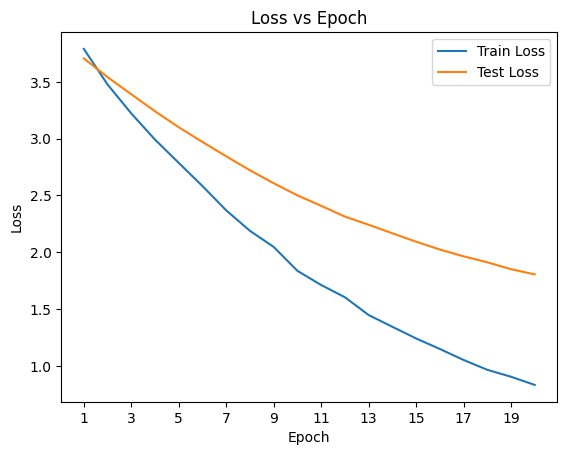

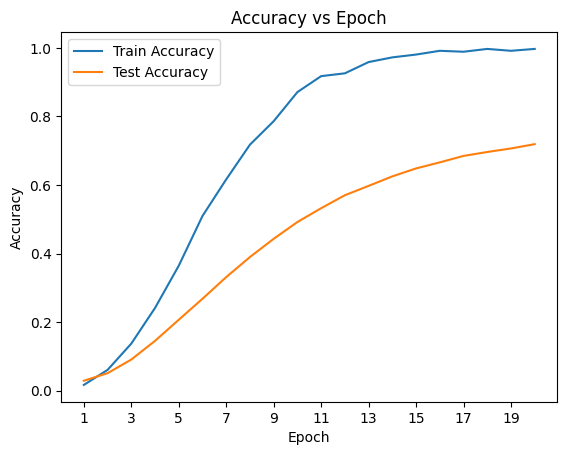


-- S1 l=3 | frac=0.1 --
Epoch 1/20 | Train loss: 3.7221, acc: 0.0384 | Test loss: 3.5968, acc: 0.0561
Epoch 2/20 | Train loss: 3.4427, acc: 0.0932 | Test loss: 3.4507, acc: 0.0954
Epoch 3/20 | Train loss: 3.2312, acc: 0.1671 | Test loss: 3.3111, acc: 0.1349
Epoch 4/20 | Train loss: 2.9856, acc: 0.2630 | Test loss: 3.1739, acc: 0.1902
Epoch 5/20 | Train loss: 2.7659, acc: 0.3890 | Test loss: 3.0449, acc: 0.2412
Epoch 6/20 | Train loss: 2.6080, acc: 0.4904 | Test loss: 2.9150, acc: 0.3012
Epoch 7/20 | Train loss: 2.3880, acc: 0.6192 | Test loss: 2.7983, acc: 0.3581
Epoch 8/20 | Train loss: 2.2116, acc: 0.7014 | Test loss: 2.6871, acc: 0.4107
Epoch 9/20 | Train loss: 2.0487, acc: 0.7671 | Test loss: 2.5824, acc: 0.4543
Epoch 10/20 | Train loss: 1.9073, acc: 0.8247 | Test loss: 2.4756, acc: 0.4974
Epoch 11/20 | Train loss: 1.7495, acc: 0.8740 | Test loss: 2.3805, acc: 0.5397
Epoch 12/20 | Train loss: 1.6229, acc: 0.8986 | Test loss: 2.2915, acc: 0.5715
Epoch 13/20 | Train loss: 1.4880, ac

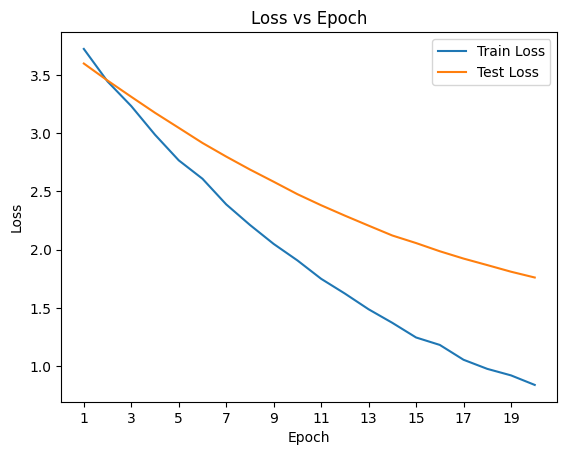

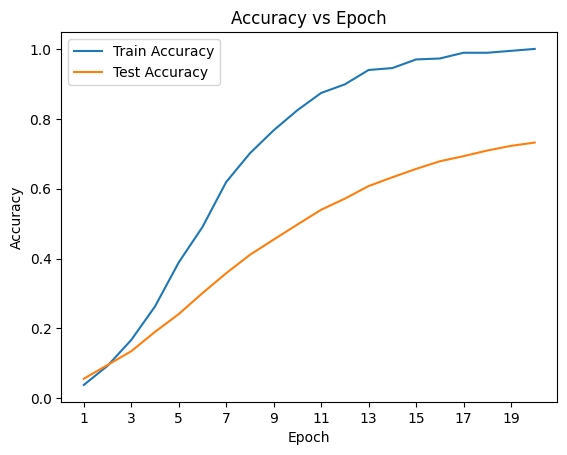


-- S1 l=4 | frac=0.1 --
Epoch 1/20 | Train loss: 3.8430, acc: 0.0219 | Test loss: 3.7007, acc: 0.0264
Epoch 2/20 | Train loss: 3.5571, acc: 0.0630 | Test loss: 3.5347, acc: 0.0493
Epoch 3/20 | Train loss: 3.2869, acc: 0.1178 | Test loss: 3.3859, acc: 0.0812
Epoch 4/20 | Train loss: 3.0656, acc: 0.2027 | Test loss: 3.2468, acc: 0.1167
Epoch 5/20 | Train loss: 2.8459, acc: 0.3534 | Test loss: 3.1086, acc: 0.1714
Epoch 6/20 | Train loss: 2.6403, acc: 0.4740 | Test loss: 2.9791, acc: 0.2374
Epoch 7/20 | Train loss: 2.4457, acc: 0.5781 | Test loss: 2.8538, acc: 0.3025
Epoch 8/20 | Train loss: 2.2552, acc: 0.7068 | Test loss: 2.7391, acc: 0.3786
Epoch 9/20 | Train loss: 2.0732, acc: 0.8164 | Test loss: 2.6260, acc: 0.4475
Epoch 10/20 | Train loss: 1.9179, acc: 0.8603 | Test loss: 2.5224, acc: 0.5012
Epoch 11/20 | Train loss: 1.7720, acc: 0.9205 | Test loss: 2.4238, acc: 0.5478
Epoch 12/20 | Train loss: 1.6688, acc: 0.9288 | Test loss: 2.3234, acc: 0.5797
Epoch 13/20 | Train loss: 1.5397, ac

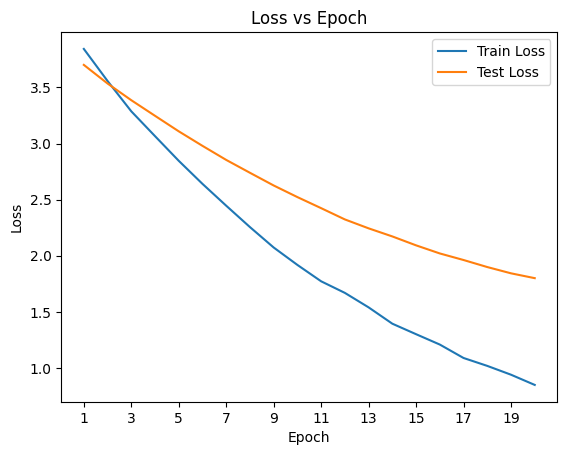

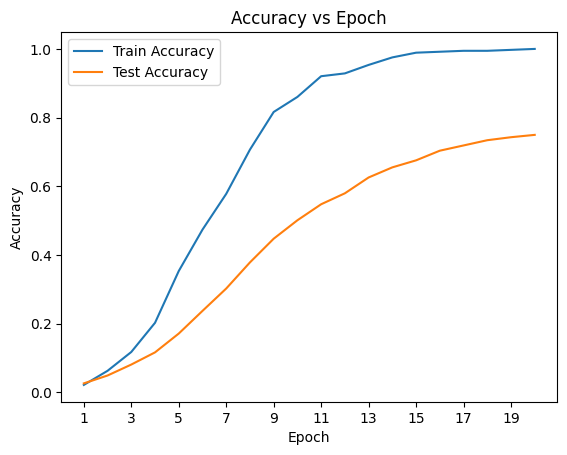


-- S2 stage=1 | frac=0.1 --
Epoch 1/5 | Train loss: 3.8483, acc: 0.0192 | Test loss: 3.7633, acc: 0.0324
Epoch 2/5 | Train loss: 3.5870, acc: 0.0521 | Test loss: 3.6110, acc: 0.0488
Epoch 3/5 | Train loss: 3.3243, acc: 0.0822 | Test loss: 3.4684, acc: 0.0630
Epoch 4/5 | Train loss: 3.1224, acc: 0.1315 | Test loss: 3.3239, acc: 0.0820
Epoch 5/5 | Train loss: 2.8993, acc: 0.1890 | Test loss: 3.1917, acc: 0.1074

-- S2 stage=2 | frac=0.1 --
Epoch 1/5 | Train loss: 2.7304, acc: 0.2603 | Test loss: 3.0510, acc: 0.1494
Epoch 2/5 | Train loss: 2.4759, acc: 0.4247 | Test loss: 2.9151, acc: 0.2096
Epoch 3/5 | Train loss: 2.3062, acc: 0.5616 | Test loss: 2.7915, acc: 0.2537
Epoch 4/5 | Train loss: 2.1206, acc: 0.7096 | Test loss: 2.6717, acc: 0.3262
Epoch 5/5 | Train loss: 1.9351, acc: 0.7973 | Test loss: 2.5657, acc: 0.3941

-- S2 stage=3 | frac=0.1 --
Epoch 1/5 | Train loss: 1.8039, acc: 0.8466 | Test loss: 2.4469, acc: 0.4519
Epoch 2/5 | Train loss: 1.6472, acc: 0.9014 | Test loss: 2.3334, a

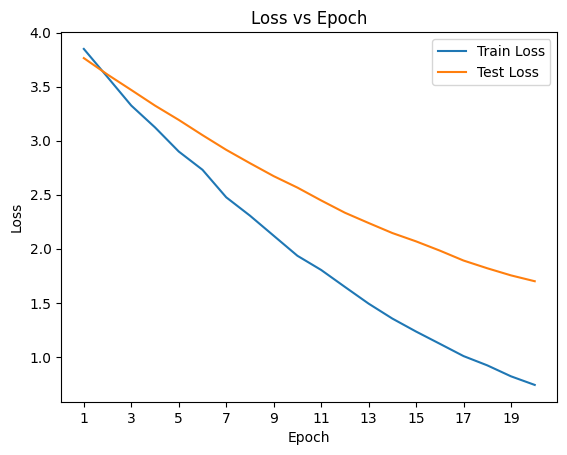

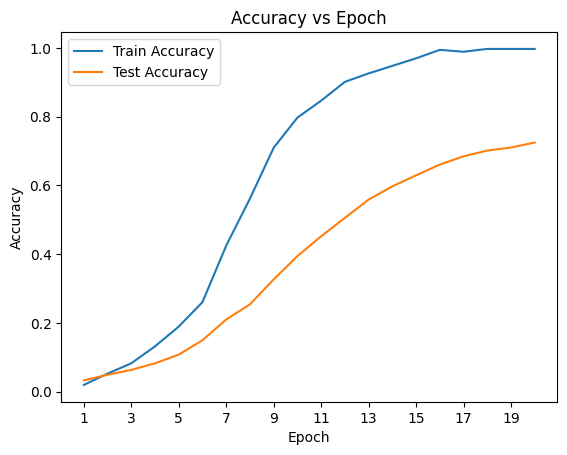


FRACTION: 1%

-- S1 l=1 | frac=0.01 --
Epoch 1/20 | Train loss: 3.9702, acc: 0.0270 | Test loss: 3.8937, acc: 0.0278
Epoch 2/20 | Train loss: 3.7597, acc: 0.0270 | Test loss: 3.8620, acc: 0.0305
Epoch 3/20 | Train loss: 3.7900, acc: 0.0541 | Test loss: 3.8385, acc: 0.0316
Epoch 4/20 | Train loss: 3.5612, acc: 0.1081 | Test loss: 3.8197, acc: 0.0324
Epoch 5/20 | Train loss: 3.4762, acc: 0.1081 | Test loss: 3.8030, acc: 0.0354
Epoch 6/20 | Train loss: 3.3901, acc: 0.1081 | Test loss: 3.7876, acc: 0.0371
Epoch 7/20 | Train loss: 3.4134, acc: 0.1351 | Test loss: 3.7704, acc: 0.0382
Epoch 8/20 | Train loss: 3.3395, acc: 0.1622 | Test loss: 3.7565, acc: 0.0392
Epoch 9/20 | Train loss: 3.0803, acc: 0.1622 | Test loss: 3.7406, acc: 0.0403
Epoch 10/20 | Train loss: 3.1253, acc: 0.2703 | Test loss: 3.7249, acc: 0.0420
Epoch 11/20 | Train loss: 2.7519, acc: 0.3514 | Test loss: 3.7089, acc: 0.0439
Epoch 12/20 | Train loss: 2.9605, acc: 0.3784 | Test loss: 3.6995, acc: 0.0447
Epoch 13/20 | Train l

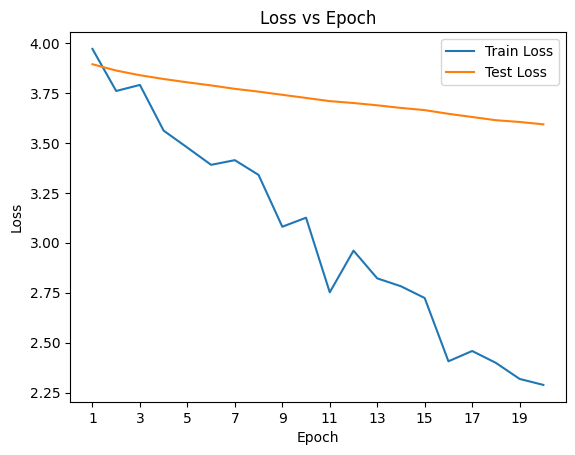

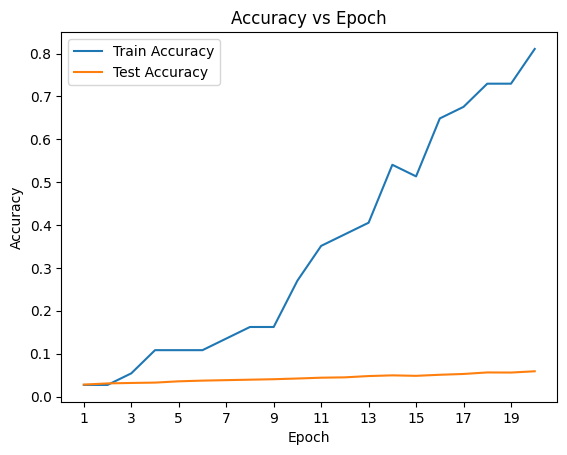


-- S1 l=2 | frac=0.01 --
Epoch 1/20 | Train loss: 3.7562, acc: 0.0270 | Test loss: 3.8014, acc: 0.0319
Epoch 2/20 | Train loss: 3.8138, acc: 0.0270 | Test loss: 3.7803, acc: 0.0322
Epoch 3/20 | Train loss: 3.6224, acc: 0.0270 | Test loss: 3.7584, acc: 0.0330
Epoch 4/20 | Train loss: 3.3396, acc: 0.0541 | Test loss: 3.7444, acc: 0.0335
Epoch 5/20 | Train loss: 3.1307, acc: 0.0811 | Test loss: 3.7276, acc: 0.0349
Epoch 6/20 | Train loss: 3.2664, acc: 0.0541 | Test loss: 3.7159, acc: 0.0365
Epoch 7/20 | Train loss: 3.1913, acc: 0.1351 | Test loss: 3.7013, acc: 0.0371
Epoch 8/20 | Train loss: 3.2493, acc: 0.1351 | Test loss: 3.6824, acc: 0.0373
Epoch 9/20 | Train loss: 2.9375, acc: 0.1622 | Test loss: 3.6673, acc: 0.0382
Epoch 10/20 | Train loss: 2.8855, acc: 0.2162 | Test loss: 3.6519, acc: 0.0384
Epoch 11/20 | Train loss: 2.9380, acc: 0.2162 | Test loss: 3.6354, acc: 0.0390
Epoch 12/20 | Train loss: 2.7853, acc: 0.2703 | Test loss: 3.6228, acc: 0.0412
Epoch 13/20 | Train loss: 2.8983, a

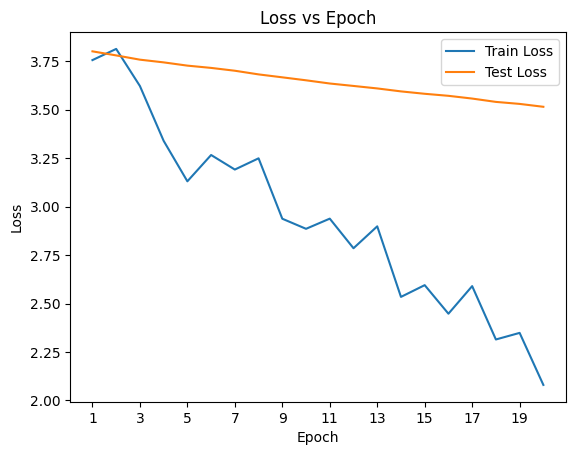

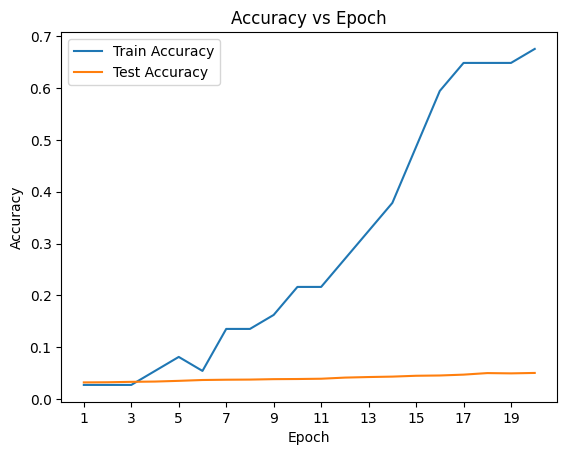


-- S1 l=3 | frac=0.01 --
Epoch 1/20 | Train loss: 3.9049, acc: 0.0811 | Test loss: 3.8086, acc: 0.0409
Epoch 2/20 | Train loss: 3.6723, acc: 0.0811 | Test loss: 3.7901, acc: 0.0436
Epoch 3/20 | Train loss: 3.5954, acc: 0.1081 | Test loss: 3.7729, acc: 0.0469
Epoch 4/20 | Train loss: 3.5754, acc: 0.1081 | Test loss: 3.7537, acc: 0.0472
Epoch 5/20 | Train loss: 3.2614, acc: 0.1351 | Test loss: 3.7408, acc: 0.0488
Epoch 6/20 | Train loss: 3.2896, acc: 0.1622 | Test loss: 3.7257, acc: 0.0510
Epoch 7/20 | Train loss: 2.9501, acc: 0.1351 | Test loss: 3.7135, acc: 0.0553
Epoch 8/20 | Train loss: 3.4117, acc: 0.1892 | Test loss: 3.7041, acc: 0.0548
Epoch 9/20 | Train loss: 2.9943, acc: 0.2162 | Test loss: 3.6900, acc: 0.0561
Epoch 10/20 | Train loss: 3.0884, acc: 0.2703 | Test loss: 3.6747, acc: 0.0567
Epoch 11/20 | Train loss: 2.9767, acc: 0.2703 | Test loss: 3.6590, acc: 0.0581
Epoch 12/20 | Train loss: 2.7745, acc: 0.2703 | Test loss: 3.6498, acc: 0.0602
Epoch 13/20 | Train loss: 2.9487, a

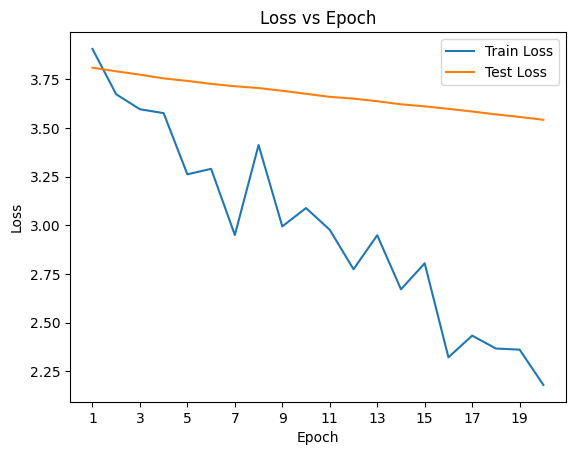

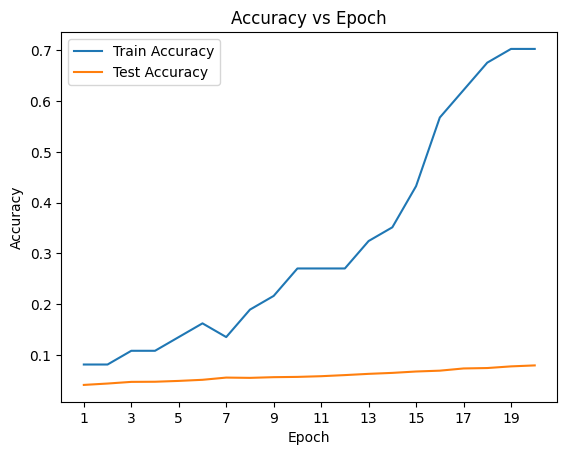


-- S1 l=4 | frac=0.01 --
Epoch 1/20 | Train loss: 3.8735, acc: 0.0270 | Test loss: 3.8181, acc: 0.0422
Epoch 2/20 | Train loss: 3.8295, acc: 0.0811 | Test loss: 3.7957, acc: 0.0431
Epoch 3/20 | Train loss: 3.6387, acc: 0.0541 | Test loss: 3.7817, acc: 0.0433
Epoch 4/20 | Train loss: 3.5993, acc: 0.0811 | Test loss: 3.7649, acc: 0.0463
Epoch 5/20 | Train loss: 3.3095, acc: 0.0811 | Test loss: 3.7424, acc: 0.0499
Epoch 6/20 | Train loss: 3.3463, acc: 0.0811 | Test loss: 3.7265, acc: 0.0496
Epoch 7/20 | Train loss: 3.2221, acc: 0.1622 | Test loss: 3.7125, acc: 0.0512
Epoch 8/20 | Train loss: 2.9107, acc: 0.1351 | Test loss: 3.7022, acc: 0.0504
Epoch 9/20 | Train loss: 3.1754, acc: 0.2432 | Test loss: 3.6883, acc: 0.0496
Epoch 10/20 | Train loss: 2.8247, acc: 0.2162 | Test loss: 3.6745, acc: 0.0488
Epoch 11/20 | Train loss: 2.9376, acc: 0.2973 | Test loss: 3.6621, acc: 0.0504
Epoch 12/20 | Train loss: 2.7810, acc: 0.2973 | Test loss: 3.6496, acc: 0.0510
Epoch 13/20 | Train loss: 2.8041, a

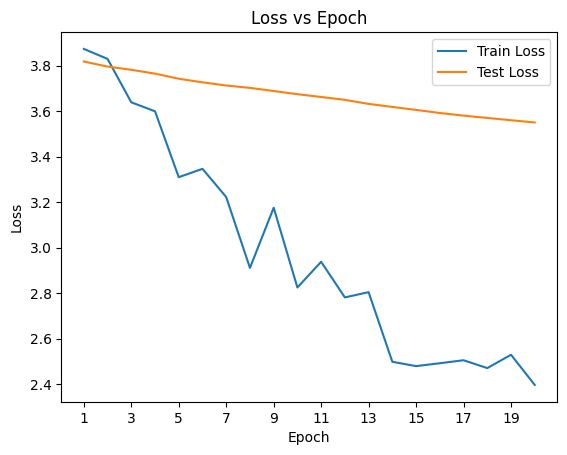

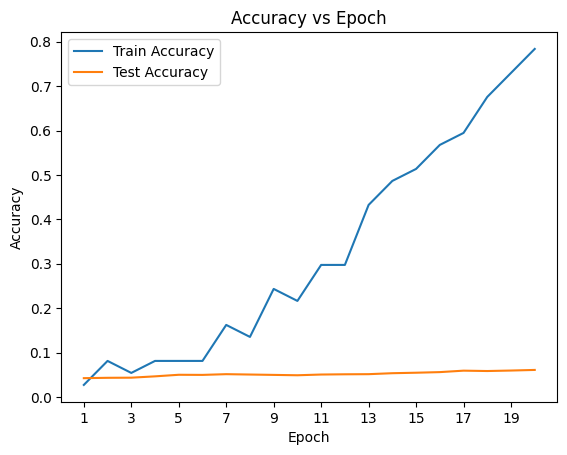


-- S2 stage=1 | frac=0.01 --
Epoch 1/5 | Train loss: 3.7609, acc: 0.0541 | Test loss: 3.9191, acc: 0.0128
Epoch 2/5 | Train loss: 3.8839, acc: 0.0541 | Test loss: 3.8912, acc: 0.0174
Epoch 3/5 | Train loss: 3.7617, acc: 0.0811 | Test loss: 3.8691, acc: 0.0213
Epoch 4/5 | Train loss: 3.3683, acc: 0.0541 | Test loss: 3.8453, acc: 0.0226
Epoch 5/5 | Train loss: 3.4366, acc: 0.1622 | Test loss: 3.8284, acc: 0.0243

-- S2 stage=2 | frac=0.01 --
Epoch 1/5 | Train loss: 3.1871, acc: 0.1622 | Test loss: 3.7962, acc: 0.0286
Epoch 2/5 | Train loss: 3.0586, acc: 0.1892 | Test loss: 3.7732, acc: 0.0343
Epoch 3/5 | Train loss: 3.0566, acc: 0.2432 | Test loss: 3.7509, acc: 0.0357
Epoch 4/5 | Train loss: 3.0932, acc: 0.2973 | Test loss: 3.7333, acc: 0.0371
Epoch 5/5 | Train loss: 2.8279, acc: 0.3243 | Test loss: 3.7179, acc: 0.0409

-- S2 stage=3 | frac=0.01 --
Epoch 1/5 | Train loss: 2.7972, acc: 0.4324 | Test loss: 3.6926, acc: 0.0433
Epoch 2/5 | Train loss: 2.8381, acc: 0.5135 | Test loss: 3.6764

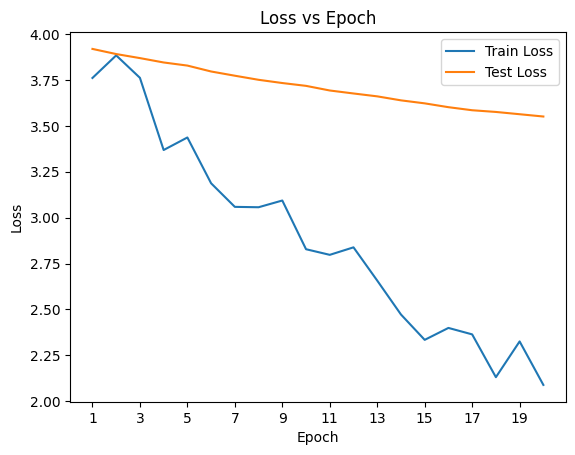

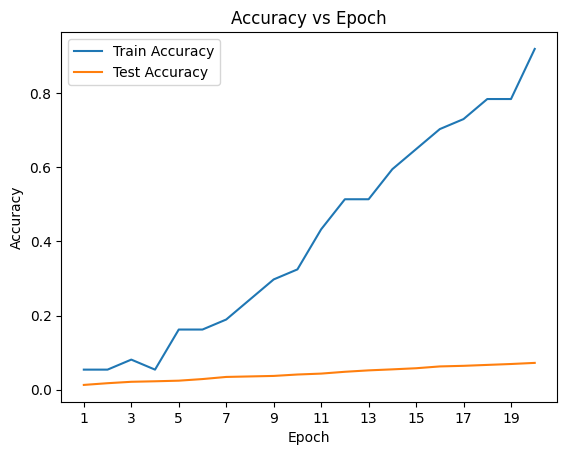


====== SUMMARY TABLE ======
Fraction   S1 l=1     S1 l=2     S1 l=3     S1 l=4     S2 grad   
------------------------------------------------------------
   100%   0.9054    0.9103    0.9120    0.9139    0.9095
    10%   0.7225    0.7193    0.7321    0.7498    0.7247
     1%   0.0589    0.0501    0.0793    0.0608    0.0722


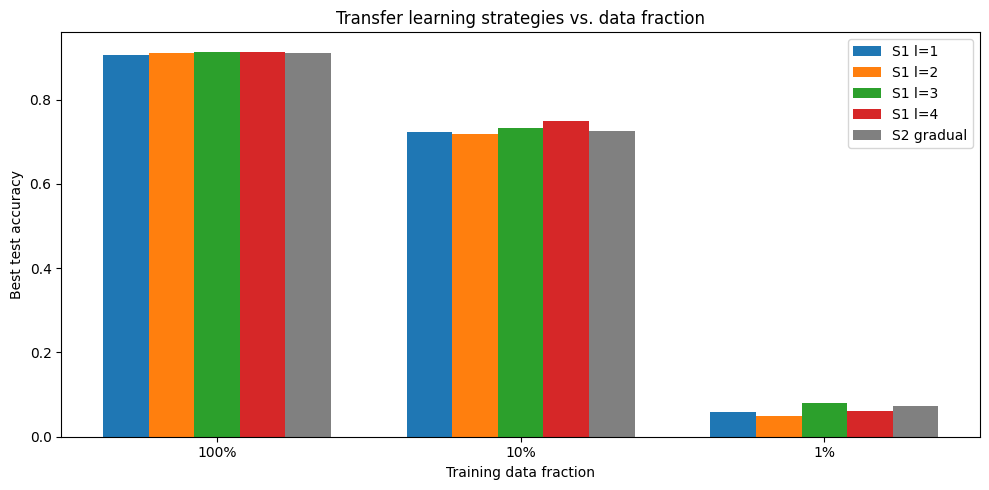

In [8]:
importlib.reload(bp)

FRACTIONS   = [1.0, 0.1, 0.01]
NUM_EPOCHS  = 20
BASE_LR     = 1e-5
strategy1_results = {}
strategy2_results = {}

test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

for frac in FRACTIONS:
    print(f"\n{'='*60}\nFRACTION: {frac*100:.0f}%\n{'='*60}")
    subset      = bp.get_stratified_subset(train_data, frac)
    frac_loader = DataLoader(subset, batch_size=32, shuffle=True, num_workers=2)

    # Strategy 1
    strategy1_results[frac] = {}
    for l in range(1, 5):
        model     = bp.get_model_finetune(num_classes=37).to(device)
        bp.unfreeze_layers(model, l)
        optimizer = bp.get_optimizer(model, l, base_lr=BASE_LR)
        criterion = nn.CrossEntropyLoss()

        print(f"\n-- S1 l={l} | frac={frac} --")
        train_losses, test_losses, train_accs, test_accs, _, best_acc = bp.train_with_history(
            model, frac_loader, test_loader, optimizer, criterion, device, num_epochs=NUM_EPOCHS
        )
        bp.plot_training_curves(train_losses, test_losses, train_accs, test_accs)
        strategy1_results[frac][l] = best_acc

    # Strategy 2
    model     = bp.get_model_finetune(num_classes=37).to(device)
    criterion = nn.CrossEntropyLoss()
    strategy2_best = 0.0
    all_train_losses, all_test_losses, all_train_accs, all_test_accs = [], [], [], []

    for stage in range(4):
        bp.unfreeze_layers(model, stage + 1)
        optimizer = bp.get_optimizer(model, stage + 1, base_lr=BASE_LR)
        print(f"\n-- S2 stage={stage+1} | frac={frac} --")
        train_losses, test_losses, train_accs, test_accs, _, best_acc = bp.train_with_history(
            model, frac_loader, test_loader, optimizer, criterion, device, num_epochs=5
        )
        all_train_losses += train_losses
        all_test_losses  += test_losses
        all_train_accs   += train_accs
        all_test_accs    += test_accs
        strategy2_best    = max(strategy2_best, best_acc)

    bp.plot_training_curves(all_train_losses, all_test_losses, all_train_accs, all_test_accs)
    strategy2_results[frac] = strategy2_best

bp.print_summary(strategy1_results, strategy2_results, FRACTIONS)
bp.plot_fraction_comparison(strategy1_results, strategy2_results, FRACTIONS)

### Save result

In [10]:
importlib.reload(bp)
bp.save_limited_data_results(
    strategy1_results,
    strategy2_results,
    FRACTIONS
)

Results saved successfully to limited_data_results.pkl


### Analyze result

In [23]:
importlib.reload(bp)
strategy1_results, strategy2_results, FRACTIONS = bp.load_limited_data_results()
print("\n" + "-"*30)
print("LIMITED DATA ANALYSIS")
print("-"*30)

for frac in FRACTIONS:

    print(f"\nFraction: {frac*100:.0f}%")

    best_l = max(
        strategy1_results[frac],
        key=strategy1_results[frac].get
    )
    best_s1 = strategy1_results[frac][best_l]

    best_s2 = strategy2_results[frac]

    print(f"Best Strategy 1: l={best_l}, accuracy={best_s1:.4f}")
    print(f"Strategy 2 accuracy: {best_s2:.4f}")

    if best_s1 > best_s2:
        print("-> Strategy 1 performed better.")
    elif best_s2 > best_s1:
        print("-> Strategy 2 performed better.")
    else:
        print("-> Both strategies performed similarly.")


# performance drop
print("\n" + "-"*30)
print("PERFORMANCE DEGRADATION")
print("-"*30)

best_full = max(strategy1_results[1.0].values())

for frac in [0.1, 0.01]:

    best_frac = max(strategy1_results[frac].values())

    drop = best_full - best_frac

    print(f"\n100% -> {frac*100:.0f}% data")

    print(f"Best accuracy at 100% : {best_full:.4f}")
    print(f"Best accuracy at {frac*100:.0f}% : {best_frac:.4f}")
    print(f"Accuracy drop : {drop:.4f}")


------------------------------
LIMITED DATA ANALYSIS
------------------------------

Fraction: 100%
Best Strategy 1: l=4, accuracy=0.9139
Strategy 2 accuracy: 0.9095
-> Strategy 1 performed better.

Fraction: 10%
Best Strategy 1: l=4, accuracy=0.7498
Strategy 2 accuracy: 0.7247
-> Strategy 1 performed better.

Fraction: 1%
Best Strategy 1: l=3, accuracy=0.0793
Strategy 2 accuracy: 0.0722
-> Strategy 1 performed better.

------------------------------
PERFORMANCE DEGRADATION
------------------------------

100% -> 10% data
Best accuracy at 100% : 0.9139
Best accuracy at 10% : 0.7498
Accuracy drop : 0.1641

100% -> 1% data
Best accuracy at 100% : 0.9139
Best accuracy at 1% : 0.0793
Accuracy drop : 0.8346


### Round 2 - Smaller batch size with reduced data


FRACTION: 100%

-- S1 l=1 | frac=1.0 --
Epoch 1/20 | Train loss: 3.0733, acc: 0.2416 | Test loss: 2.3676, acc: 0.5448
Epoch 2/20 | Train loss: 1.9461, acc: 0.7030 | Test loss: 1.5210, acc: 0.7972
Epoch 3/20 | Train loss: 1.3046, acc: 0.8511 | Test loss: 1.0683, acc: 0.8591
Epoch 4/20 | Train loss: 0.9383, acc: 0.8997 | Test loss: 0.8096, acc: 0.8795
Epoch 5/20 | Train loss: 0.7158, acc: 0.9209 | Test loss: 0.6704, acc: 0.8874
Epoch 6/20 | Train loss: 0.5725, acc: 0.9334 | Test loss: 0.5766, acc: 0.8948
Epoch 7/20 | Train loss: 0.4663, acc: 0.9446 | Test loss: 0.5228, acc: 0.8975
Epoch 8/20 | Train loss: 0.3815, acc: 0.9527 | Test loss: 0.4774, acc: 0.9008
Epoch 9/20 | Train loss: 0.3210, acc: 0.9636 | Test loss: 0.4500, acc: 0.9019
Epoch 10/20 | Train loss: 0.2729, acc: 0.9715 | Test loss: 0.4218, acc: 0.9038
Epoch 11/20 | Train loss: 0.2220, acc: 0.9777 | Test loss: 0.4025, acc: 0.9013
Epoch 12/20 | Train loss: 0.1962, acc: 0.9851 | Test loss: 0.3892, acc: 0.9079
Epoch 13/20 | Train 

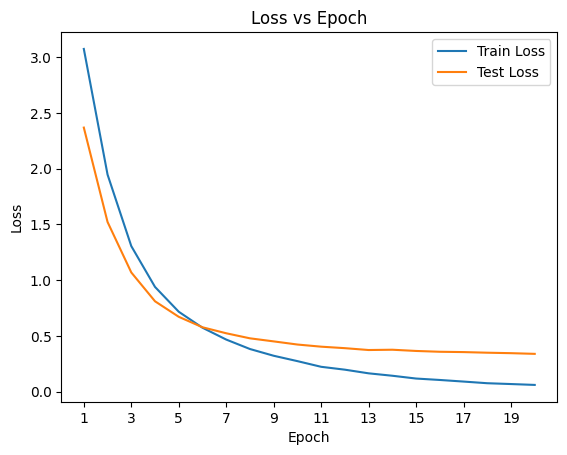

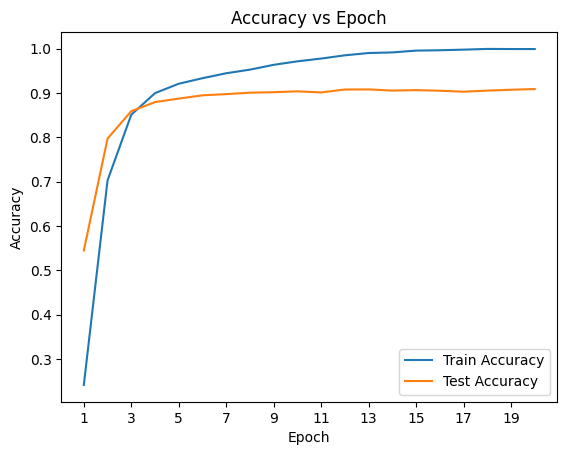


-- S1 l=2 | frac=1.0 --
Epoch 1/20 | Train loss: 3.1630, acc: 0.1837 | Test loss: 2.4271, acc: 0.4928
Epoch 2/20 | Train loss: 1.9547, acc: 0.6967 | Test loss: 1.5310, acc: 0.7885
Epoch 3/20 | Train loss: 1.2851, acc: 0.8546 | Test loss: 1.0591, acc: 0.8572
Epoch 4/20 | Train loss: 0.9122, acc: 0.9016 | Test loss: 0.8005, acc: 0.8782
Epoch 5/20 | Train loss: 0.6850, acc: 0.9255 | Test loss: 0.6580, acc: 0.8896
Epoch 6/20 | Train loss: 0.5338, acc: 0.9413 | Test loss: 0.5719, acc: 0.8915
Epoch 7/20 | Train loss: 0.4391, acc: 0.9535 | Test loss: 0.5086, acc: 0.8970
Epoch 8/20 | Train loss: 0.3534, acc: 0.9598 | Test loss: 0.4670, acc: 0.8981
Epoch 9/20 | Train loss: 0.2997, acc: 0.9663 | Test loss: 0.4435, acc: 0.8970
Epoch 10/20 | Train loss: 0.2425, acc: 0.9755 | Test loss: 0.4128, acc: 0.9008
Epoch 11/20 | Train loss: 0.1991, acc: 0.9842 | Test loss: 0.4009, acc: 0.8981
Epoch 12/20 | Train loss: 0.1754, acc: 0.9861 | Test loss: 0.3897, acc: 0.8989
Epoch 13/20 | Train loss: 0.1441, ac

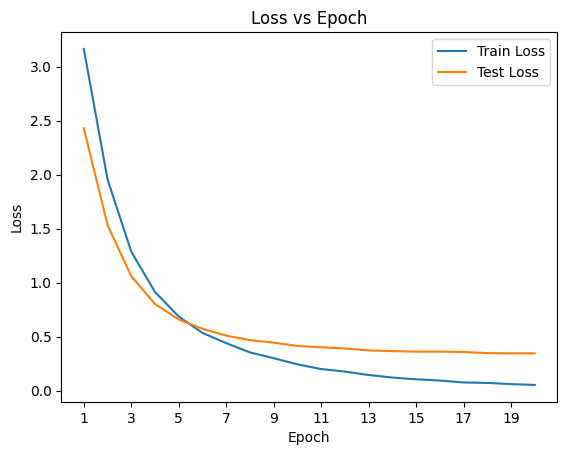

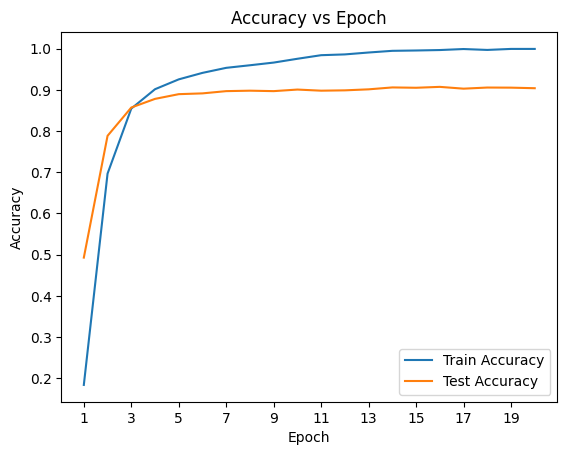


-- S1 l=3 | frac=1.0 --
Epoch 1/20 | Train loss: 3.0745, acc: 0.2389 | Test loss: 2.3637, acc: 0.5037
Epoch 2/20 | Train loss: 1.9182, acc: 0.6965 | Test loss: 1.5150, acc: 0.7855
Epoch 3/20 | Train loss: 1.2597, acc: 0.8538 | Test loss: 1.0541, acc: 0.8580
Epoch 4/20 | Train loss: 0.8958, acc: 0.8967 | Test loss: 0.7991, acc: 0.8787
Epoch 5/20 | Train loss: 0.6817, acc: 0.9187 | Test loss: 0.6588, acc: 0.8880
Epoch 6/20 | Train loss: 0.5259, acc: 0.9364 | Test loss: 0.5635, acc: 0.8932
Epoch 7/20 | Train loss: 0.4246, acc: 0.9527 | Test loss: 0.5037, acc: 0.8986
Epoch 8/20 | Train loss: 0.3478, acc: 0.9587 | Test loss: 0.4595, acc: 0.9032
Epoch 9/20 | Train loss: 0.2853, acc: 0.9677 | Test loss: 0.4403, acc: 0.8967
Epoch 10/20 | Train loss: 0.2442, acc: 0.9772 | Test loss: 0.4144, acc: 0.9046
Epoch 11/20 | Train loss: 0.2031, acc: 0.9802 | Test loss: 0.3936, acc: 0.9032
Epoch 12/20 | Train loss: 0.1659, acc: 0.9872 | Test loss: 0.3850, acc: 0.9046
Epoch 13/20 | Train loss: 0.1343, ac

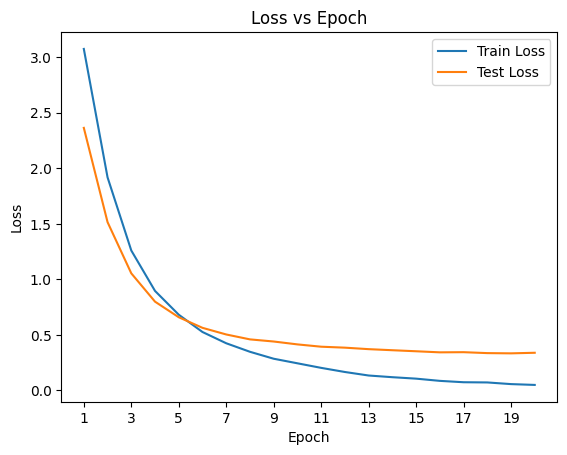

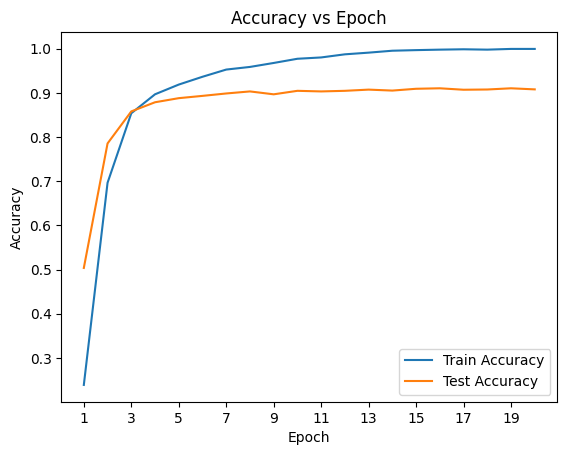


-- S1 l=4 | frac=1.0 --
Epoch 1/20 | Train loss: 3.1901, acc: 0.2117 | Test loss: 2.4625, acc: 0.5110
Epoch 2/20 | Train loss: 1.9977, acc: 0.6889 | Test loss: 1.5594, acc: 0.7836
Epoch 3/20 | Train loss: 1.3032, acc: 0.8432 | Test loss: 1.0842, acc: 0.8564
Epoch 4/20 | Train loss: 0.9210, acc: 0.8989 | Test loss: 0.8181, acc: 0.8839
Epoch 5/20 | Train loss: 0.6893, acc: 0.9193 | Test loss: 0.6723, acc: 0.8918
Epoch 6/20 | Train loss: 0.5404, acc: 0.9389 | Test loss: 0.5744, acc: 0.8994
Epoch 7/20 | Train loss: 0.4355, acc: 0.9454 | Test loss: 0.5149, acc: 0.8997
Epoch 8/20 | Train loss: 0.3552, acc: 0.9609 | Test loss: 0.4674, acc: 0.9027
Epoch 9/20 | Train loss: 0.2922, acc: 0.9688 | Test loss: 0.4390, acc: 0.9076
Epoch 10/20 | Train loss: 0.2425, acc: 0.9764 | Test loss: 0.4123, acc: 0.9090
Epoch 11/20 | Train loss: 0.2029, acc: 0.9845 | Test loss: 0.3974, acc: 0.9054
Epoch 12/20 | Train loss: 0.1698, acc: 0.9894 | Test loss: 0.3871, acc: 0.9060
Epoch 13/20 | Train loss: 0.1476, ac

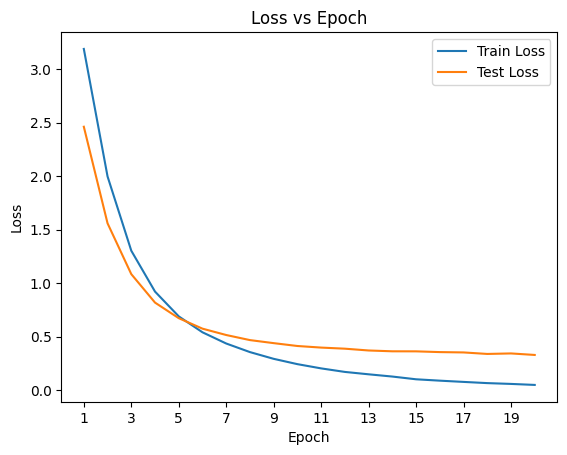

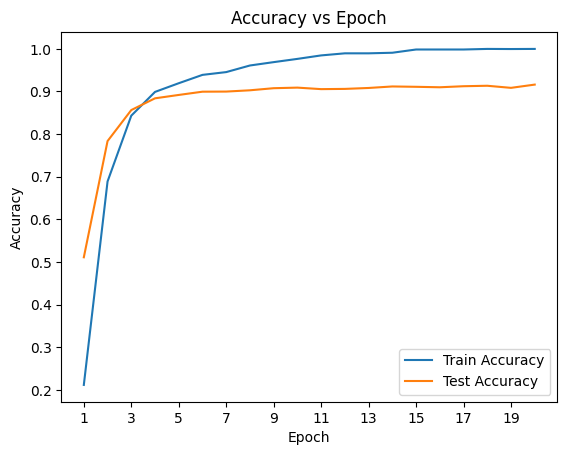


-- S2 stage=1 | frac=1.0 --
Epoch 1/5 | Train loss: 3.1448, acc: 0.2084 | Test loss: 2.3934, acc: 0.4917
Epoch 2/5 | Train loss: 1.9704, acc: 0.6696 | Test loss: 1.5135, acc: 0.7978
Epoch 3/5 | Train loss: 1.3062, acc: 0.8541 | Test loss: 1.0716, acc: 0.8572
Epoch 4/5 | Train loss: 0.9287, acc: 0.8997 | Test loss: 0.8132, acc: 0.8839
Epoch 5/5 | Train loss: 0.7099, acc: 0.9207 | Test loss: 0.6788, acc: 0.8899

-- S2 stage=2 | frac=1.0 --
Epoch 1/5 | Train loss: 0.5431, acc: 0.9315 | Test loss: 0.5467, acc: 0.8962
Epoch 2/5 | Train loss: 0.4097, acc: 0.9497 | Test loss: 0.4816, acc: 0.9011
Epoch 3/5 | Train loss: 0.3164, acc: 0.9668 | Test loss: 0.4324, acc: 0.9049
Epoch 4/5 | Train loss: 0.2513, acc: 0.9761 | Test loss: 0.4076, acc: 0.9049
Epoch 5/5 | Train loss: 0.2014, acc: 0.9826 | Test loss: 0.3877, acc: 0.9081

-- S2 stage=3 | frac=1.0 --
Epoch 1/5 | Train loss: 0.1589, acc: 0.9878 | Test loss: 0.3740, acc: 0.9122
Epoch 2/5 | Train loss: 0.1215, acc: 0.9921 | Test loss: 0.3560, a

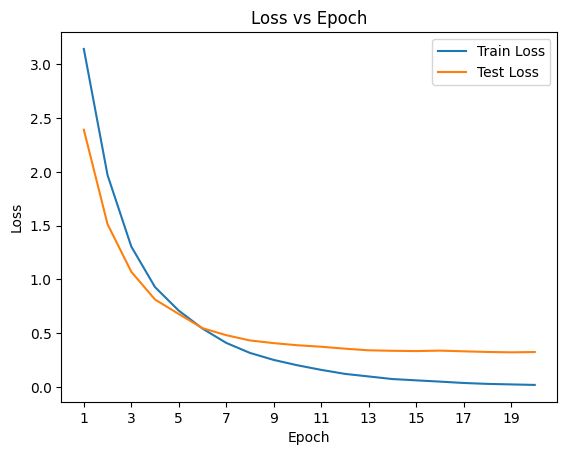

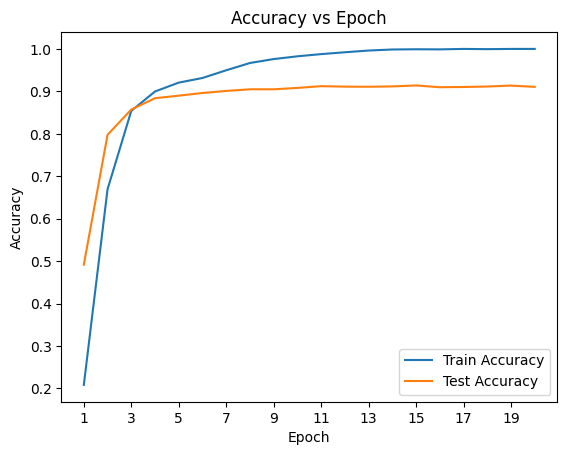


FRACTION: 10%

-- S1 l=1 | frac=0.1 --
Epoch 1/20 | Train loss: 3.7808, acc: 0.0247 | Test loss: 3.6790, acc: 0.0439
Epoch 2/20 | Train loss: 3.5093, acc: 0.0658 | Test loss: 3.5219, acc: 0.0690
Epoch 3/20 | Train loss: 3.2900, acc: 0.1233 | Test loss: 3.3808, acc: 0.1055
Epoch 4/20 | Train loss: 3.0464, acc: 0.2055 | Test loss: 3.2372, acc: 0.1483
Epoch 5/20 | Train loss: 2.8551, acc: 0.3178 | Test loss: 3.1016, acc: 0.2071
Epoch 6/20 | Train loss: 2.6513, acc: 0.4822 | Test loss: 2.9732, acc: 0.2660
Epoch 7/20 | Train loss: 2.4494, acc: 0.5973 | Test loss: 2.8482, acc: 0.3366
Epoch 8/20 | Train loss: 2.2619, acc: 0.6932 | Test loss: 2.7271, acc: 0.4056
Epoch 9/20 | Train loss: 2.1161, acc: 0.7726 | Test loss: 2.6124, acc: 0.4655
Epoch 10/20 | Train loss: 1.9299, acc: 0.8274 | Test loss: 2.5120, acc: 0.5086
Epoch 11/20 | Train loss: 1.7957, acc: 0.8959 | Test loss: 2.4179, acc: 0.5440
Epoch 12/20 | Train loss: 1.6495, acc: 0.9260 | Test loss: 2.3299, acc: 0.5740
Epoch 13/20 | Train l

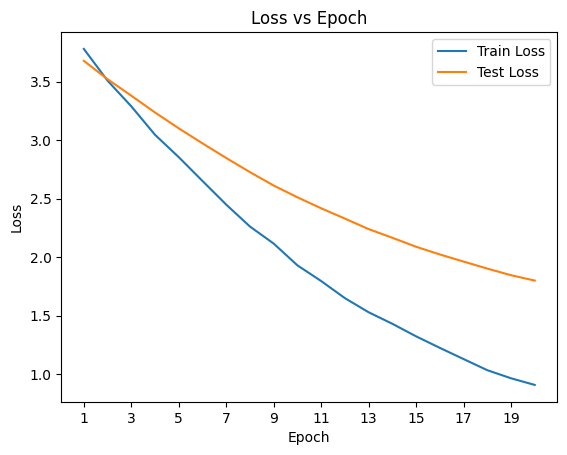

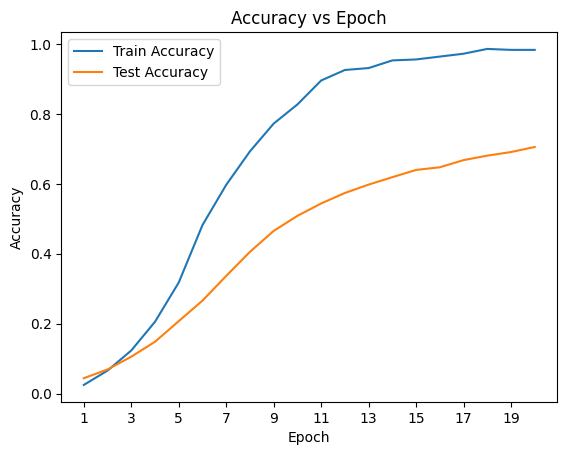


-- S1 l=2 | frac=0.1 --
Epoch 1/20 | Train loss: 3.8078, acc: 0.0274 | Test loss: 3.7198, acc: 0.0403
Epoch 2/20 | Train loss: 3.5411, acc: 0.0740 | Test loss: 3.5548, acc: 0.0567
Epoch 3/20 | Train loss: 3.2680, acc: 0.1260 | Test loss: 3.4027, acc: 0.0769
Epoch 4/20 | Train loss: 3.0449, acc: 0.1836 | Test loss: 3.2566, acc: 0.1049
Epoch 5/20 | Train loss: 2.8105, acc: 0.2658 | Test loss: 3.1202, acc: 0.1469
Epoch 6/20 | Train loss: 2.6254, acc: 0.3918 | Test loss: 2.9857, acc: 0.1990
Epoch 7/20 | Train loss: 2.4276, acc: 0.5123 | Test loss: 2.8548, acc: 0.2726
Epoch 8/20 | Train loss: 2.2264, acc: 0.6767 | Test loss: 2.7360, acc: 0.3325
Epoch 9/20 | Train loss: 2.0641, acc: 0.7452 | Test loss: 2.6248, acc: 0.4009
Epoch 10/20 | Train loss: 1.8922, acc: 0.8356 | Test loss: 2.5180, acc: 0.4631
Epoch 11/20 | Train loss: 1.7768, acc: 0.8849 | Test loss: 2.4177, acc: 0.5086
Epoch 12/20 | Train loss: 1.6217, acc: 0.9096 | Test loss: 2.3346, acc: 0.5601
Epoch 13/20 | Train loss: 1.5087, ac

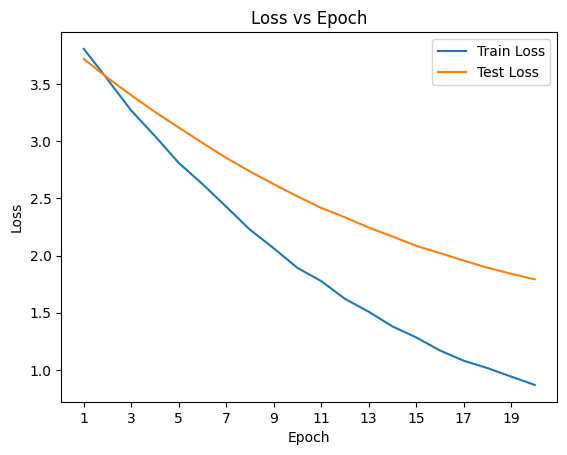

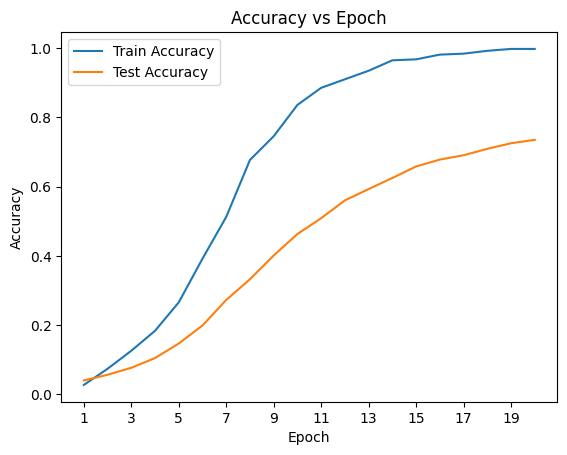


-- S1 l=3 | frac=0.1 --
Epoch 1/20 | Train loss: 3.7673, acc: 0.0493 | Test loss: 3.6287, acc: 0.0643
Epoch 2/20 | Train loss: 3.4748, acc: 0.1068 | Test loss: 3.4792, acc: 0.0919
Epoch 3/20 | Train loss: 3.2322, acc: 0.1753 | Test loss: 3.3272, acc: 0.1273
Epoch 4/20 | Train loss: 3.0083, acc: 0.2384 | Test loss: 3.1859, acc: 0.1654
Epoch 5/20 | Train loss: 2.7728, acc: 0.3151 | Test loss: 3.0480, acc: 0.2140
Epoch 6/20 | Train loss: 2.5703, acc: 0.4466 | Test loss: 2.9116, acc: 0.2717
Epoch 7/20 | Train loss: 2.3680, acc: 0.5918 | Test loss: 2.7900, acc: 0.3287
Epoch 8/20 | Train loss: 2.2082, acc: 0.6603 | Test loss: 2.6668, acc: 0.3917
Epoch 9/20 | Train loss: 2.0356, acc: 0.7671 | Test loss: 2.5554, acc: 0.4470
Epoch 10/20 | Train loss: 1.8550, acc: 0.8301 | Test loss: 2.4443, acc: 0.4969
Epoch 11/20 | Train loss: 1.7259, acc: 0.8767 | Test loss: 2.3510, acc: 0.5405
Epoch 12/20 | Train loss: 1.5882, acc: 0.9123 | Test loss: 2.2579, acc: 0.5824
Epoch 13/20 | Train loss: 1.4825, ac

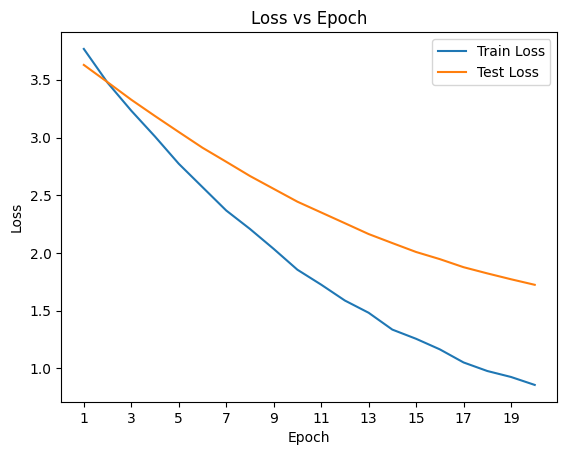

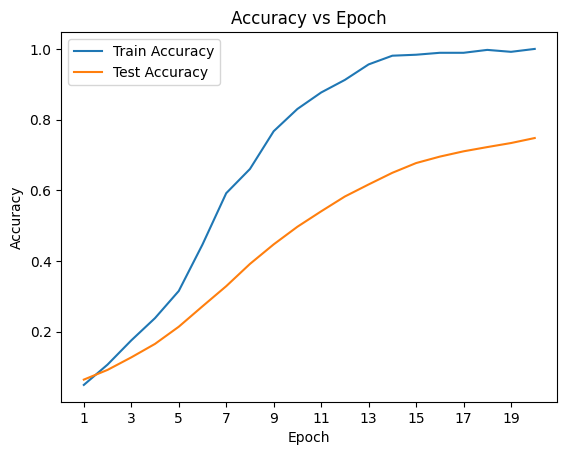


-- S1 l=4 | frac=0.1 --
Epoch 1/20 | Train loss: 3.8069, acc: 0.0274 | Test loss: 3.6716, acc: 0.0442
Epoch 2/20 | Train loss: 3.4879, acc: 0.0658 | Test loss: 3.5149, acc: 0.0714
Epoch 3/20 | Train loss: 3.2512, acc: 0.1425 | Test loss: 3.3681, acc: 0.1098
Epoch 4/20 | Train loss: 3.0157, acc: 0.2493 | Test loss: 3.2212, acc: 0.1521
Epoch 5/20 | Train loss: 2.8021, acc: 0.3836 | Test loss: 3.0825, acc: 0.2088
Epoch 6/20 | Train loss: 2.5866, acc: 0.4986 | Test loss: 2.9487, acc: 0.2630
Epoch 7/20 | Train loss: 2.4229, acc: 0.6000 | Test loss: 2.8190, acc: 0.3181
Epoch 8/20 | Train loss: 2.2156, acc: 0.7068 | Test loss: 2.7045, acc: 0.3723
Epoch 9/20 | Train loss: 2.0349, acc: 0.7808 | Test loss: 2.5890, acc: 0.4225
Epoch 10/20 | Train loss: 1.8958, acc: 0.8329 | Test loss: 2.4806, acc: 0.4756
Epoch 11/20 | Train loss: 1.7647, acc: 0.8986 | Test loss: 2.3835, acc: 0.5217
Epoch 12/20 | Train loss: 1.6043, acc: 0.9233 | Test loss: 2.2881, acc: 0.5514
Epoch 13/20 | Train loss: 1.4687, ac

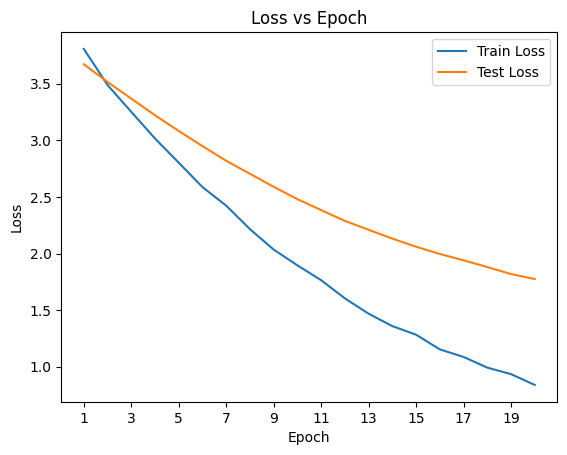

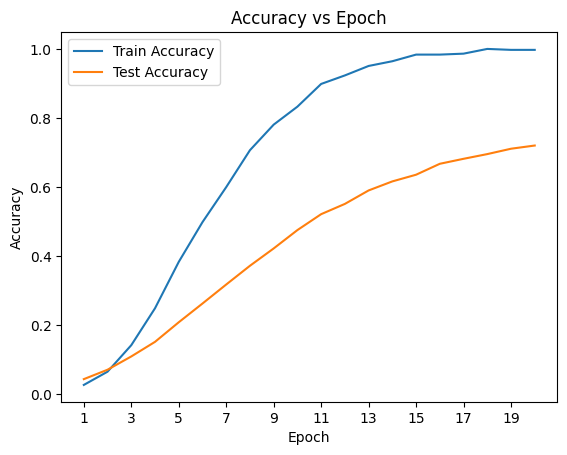


-- S2 stage=1 | frac=0.1 --
Epoch 1/5 | Train loss: 3.8114, acc: 0.0219 | Test loss: 3.6923, acc: 0.0343
Epoch 2/5 | Train loss: 3.5474, acc: 0.0493 | Test loss: 3.5364, acc: 0.0646
Epoch 3/5 | Train loss: 3.2920, acc: 0.1342 | Test loss: 3.3871, acc: 0.1123
Epoch 4/5 | Train loss: 3.0528, acc: 0.2274 | Test loss: 3.2447, acc: 0.1592
Epoch 5/5 | Train loss: 2.8881, acc: 0.3425 | Test loss: 3.1073, acc: 0.2150

-- S2 stage=2 | frac=0.1 --
Epoch 1/5 | Train loss: 2.6542, acc: 0.4795 | Test loss: 2.9610, acc: 0.2756
Epoch 2/5 | Train loss: 2.4559, acc: 0.6055 | Test loss: 2.8279, acc: 0.3380
Epoch 3/5 | Train loss: 2.2414, acc: 0.7151 | Test loss: 2.6990, acc: 0.3906
Epoch 4/5 | Train loss: 2.0423, acc: 0.8027 | Test loss: 2.5795, acc: 0.4494
Epoch 5/5 | Train loss: 1.9160, acc: 0.8630 | Test loss: 2.4702, acc: 0.5034

-- S2 stage=3 | frac=0.1 --
Epoch 1/5 | Train loss: 1.7585, acc: 0.8904 | Test loss: 2.3542, acc: 0.5497
Epoch 2/5 | Train loss: 1.5661, acc: 0.9260 | Test loss: 2.2532, a

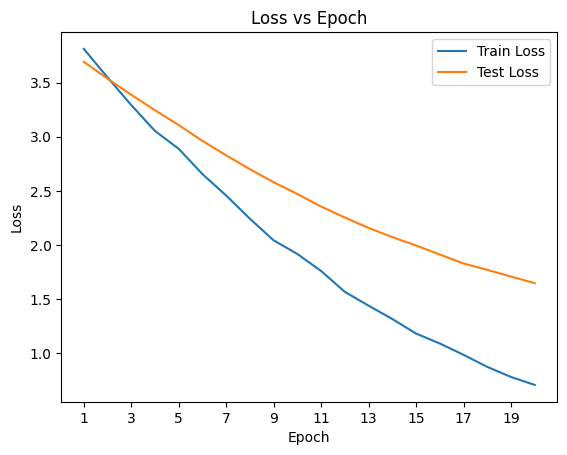

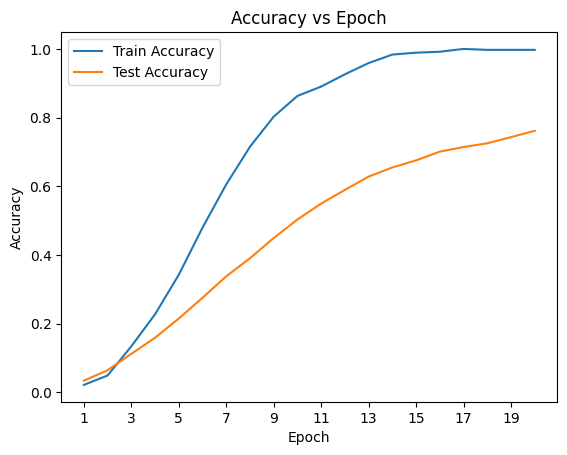


FRACTION: 1%

-- S1 l=1 | frac=0.01 --
Epoch 1/30 | Train loss: 3.8410, acc: 0.0270 | Test loss: 3.8318, acc: 0.0275
Epoch 2/30 | Train loss: 3.8790, acc: 0.0541 | Test loss: 3.8036, acc: 0.0267
Epoch 3/30 | Train loss: 3.7319, acc: 0.0811 | Test loss: 3.7749, acc: 0.0273
Epoch 4/30 | Train loss: 3.2874, acc: 0.0811 | Test loss: 3.7415, acc: 0.0333
Epoch 5/30 | Train loss: 3.3494, acc: 0.1351 | Test loss: 3.6980, acc: 0.0365
Epoch 6/30 | Train loss: 3.1392, acc: 0.1351 | Test loss: 3.6744, acc: 0.0409
Epoch 7/30 | Train loss: 3.1054, acc: 0.2432 | Test loss: 3.6518, acc: 0.0436
Epoch 8/30 | Train loss: 2.8907, acc: 0.2432 | Test loss: 3.6297, acc: 0.0403
Epoch 9/30 | Train loss: 2.9432, acc: 0.3514 | Test loss: 3.6033, acc: 0.0482
Epoch 10/30 | Train loss: 2.7984, acc: 0.3784 | Test loss: 3.5751, acc: 0.0534
Epoch 11/30 | Train loss: 2.6640, acc: 0.4595 | Test loss: 3.5478, acc: 0.0570
Epoch 12/30 | Train loss: 2.3724, acc: 0.6216 | Test loss: 3.5126, acc: 0.0630
Epoch 13/30 | Train l

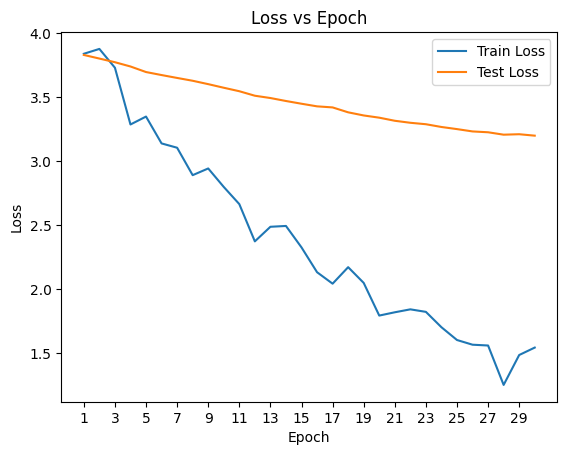

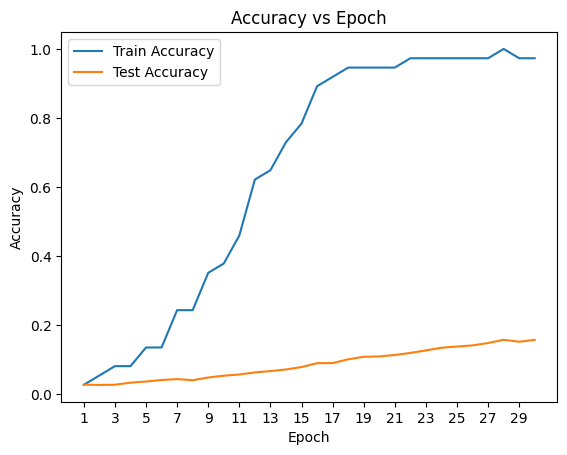


-- S1 l=2 | frac=0.01 --
Epoch 1/30 | Train loss: 3.6677, acc: 0.0541 | Test loss: 3.8503, acc: 0.0270
Epoch 2/30 | Train loss: 3.5814, acc: 0.0811 | Test loss: 3.8206, acc: 0.0297
Epoch 3/30 | Train loss: 3.4575, acc: 0.0811 | Test loss: 3.7871, acc: 0.0286
Epoch 4/30 | Train loss: 3.3981, acc: 0.1081 | Test loss: 3.7619, acc: 0.0286
Epoch 5/30 | Train loss: 3.2148, acc: 0.1081 | Test loss: 3.7335, acc: 0.0294
Epoch 6/30 | Train loss: 3.1150, acc: 0.1892 | Test loss: 3.6929, acc: 0.0362
Epoch 7/30 | Train loss: 2.7576, acc: 0.3243 | Test loss: 3.6604, acc: 0.0442
Epoch 8/30 | Train loss: 2.7234, acc: 0.4054 | Test loss: 3.6389, acc: 0.0493
Epoch 9/30 | Train loss: 2.7338, acc: 0.5946 | Test loss: 3.6144, acc: 0.0542
Epoch 10/30 | Train loss: 2.6675, acc: 0.5946 | Test loss: 3.5957, acc: 0.0600
Epoch 11/30 | Train loss: 2.5963, acc: 0.7027 | Test loss: 3.5733, acc: 0.0646
Epoch 12/30 | Train loss: 2.4137, acc: 0.7568 | Test loss: 3.5522, acc: 0.0741
Epoch 13/30 | Train loss: 2.4619, a

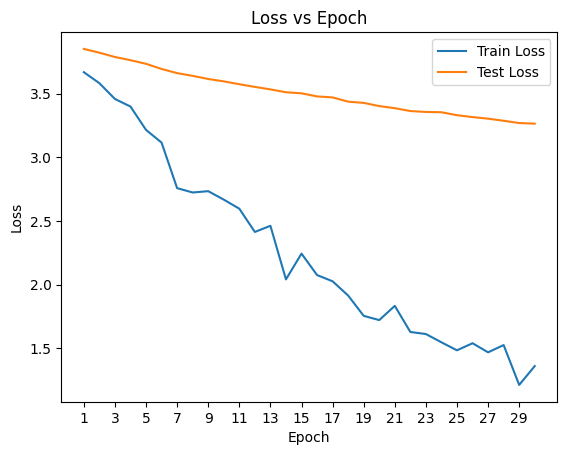

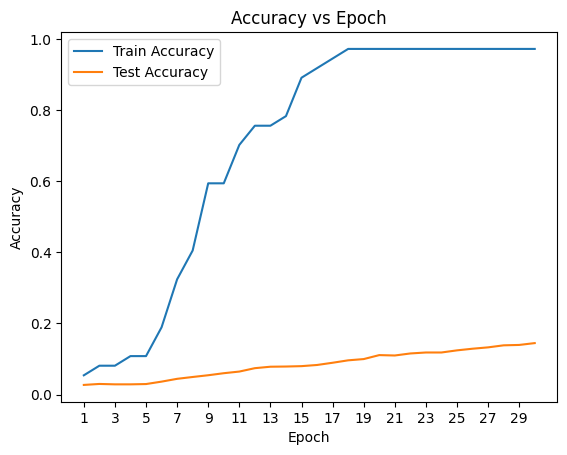


-- S1 l=3 | frac=0.01 --
Epoch 1/30 | Train loss: 3.5843, acc: 0.0541 | Test loss: 3.9551, acc: 0.0194
Epoch 2/30 | Train loss: 3.5403, acc: 0.0811 | Test loss: 3.9092, acc: 0.0232
Epoch 3/30 | Train loss: 3.3680, acc: 0.0811 | Test loss: 3.8779, acc: 0.0251
Epoch 4/30 | Train loss: 3.0818, acc: 0.1622 | Test loss: 3.8434, acc: 0.0289
Epoch 5/30 | Train loss: 3.2472, acc: 0.1892 | Test loss: 3.8055, acc: 0.0294
Epoch 6/30 | Train loss: 3.1536, acc: 0.3243 | Test loss: 3.7813, acc: 0.0308
Epoch 7/30 | Train loss: 2.9072, acc: 0.4054 | Test loss: 3.7596, acc: 0.0308
Epoch 8/30 | Train loss: 2.7904, acc: 0.3784 | Test loss: 3.7409, acc: 0.0379
Epoch 9/30 | Train loss: 2.7893, acc: 0.4324 | Test loss: 3.7146, acc: 0.0392
Epoch 10/30 | Train loss: 2.6852, acc: 0.5676 | Test loss: 3.6921, acc: 0.0412
Epoch 11/30 | Train loss: 2.4876, acc: 0.7027 | Test loss: 3.6594, acc: 0.0466
Epoch 12/30 | Train loss: 2.4859, acc: 0.6757 | Test loss: 3.6252, acc: 0.0523
Epoch 13/30 | Train loss: 2.4577, a

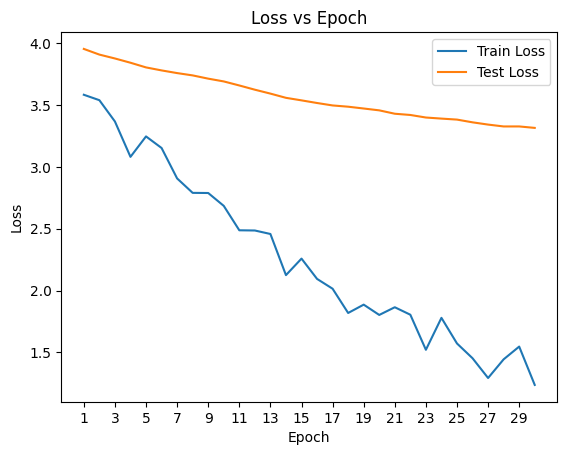

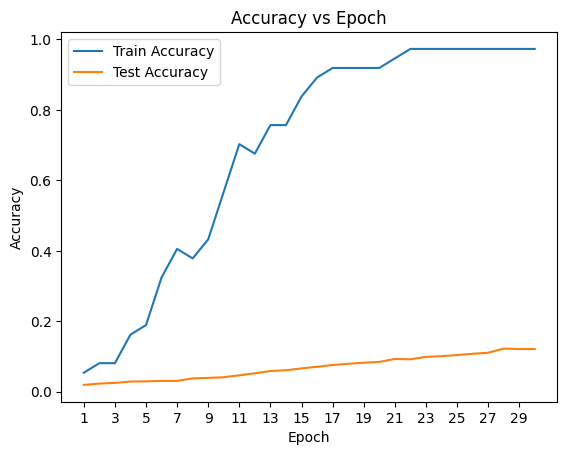


-- S1 l=4 | frac=0.01 --
Epoch 1/30 | Train loss: 3.9522, acc: 0.0270 | Test loss: 3.9204, acc: 0.0223
Epoch 2/30 | Train loss: 3.5235, acc: 0.0000 | Test loss: 3.8734, acc: 0.0259
Epoch 3/30 | Train loss: 3.5785, acc: 0.0811 | Test loss: 3.8397, acc: 0.0311
Epoch 4/30 | Train loss: 3.3480, acc: 0.1081 | Test loss: 3.8047, acc: 0.0338
Epoch 5/30 | Train loss: 3.3714, acc: 0.1622 | Test loss: 3.7791, acc: 0.0373
Epoch 6/30 | Train loss: 3.1373, acc: 0.2973 | Test loss: 3.7604, acc: 0.0412
Epoch 7/30 | Train loss: 3.1505, acc: 0.2973 | Test loss: 3.7305, acc: 0.0485
Epoch 8/30 | Train loss: 3.0399, acc: 0.4324 | Test loss: 3.7062, acc: 0.0515
Epoch 9/30 | Train loss: 2.5849, acc: 0.4865 | Test loss: 3.6747, acc: 0.0553
Epoch 10/30 | Train loss: 2.4834, acc: 0.5135 | Test loss: 3.6347, acc: 0.0613
Epoch 11/30 | Train loss: 2.6006, acc: 0.5676 | Test loss: 3.6092, acc: 0.0673
Epoch 12/30 | Train loss: 2.3650, acc: 0.6486 | Test loss: 3.5944, acc: 0.0660
Epoch 13/30 | Train loss: 2.1348, a

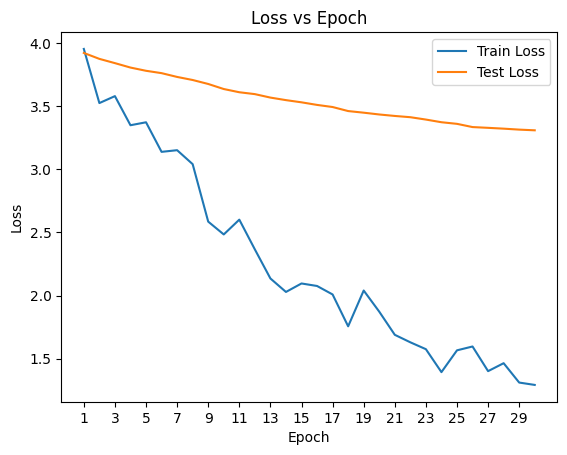

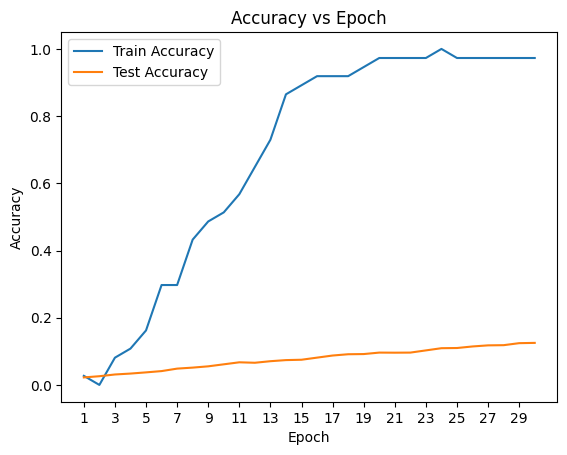


-- S2 stage=1 | frac=0.01 --
Epoch 1/7 | Train loss: 3.7155, acc: 0.0270 | Test loss: 3.7789, acc: 0.0172
Epoch 2/7 | Train loss: 3.6062, acc: 0.0000 | Test loss: 3.7369, acc: 0.0226
Epoch 3/7 | Train loss: 3.4841, acc: 0.0541 | Test loss: 3.6988, acc: 0.0278
Epoch 4/7 | Train loss: 3.3676, acc: 0.1622 | Test loss: 3.6681, acc: 0.0319
Epoch 5/7 | Train loss: 3.2436, acc: 0.1622 | Test loss: 3.6423, acc: 0.0362
Epoch 6/7 | Train loss: 3.0383, acc: 0.4595 | Test loss: 3.6133, acc: 0.0395
Epoch 7/7 | Train loss: 3.0677, acc: 0.3243 | Test loss: 3.5890, acc: 0.0472

-- S2 stage=2 | frac=0.01 --
Epoch 1/7 | Train loss: 2.7955, acc: 0.5135 | Test loss: 3.5589, acc: 0.0510
Epoch 2/7 | Train loss: 2.6695, acc: 0.6757 | Test loss: 3.5356, acc: 0.0583
Epoch 3/7 | Train loss: 2.6572, acc: 0.7568 | Test loss: 3.5080, acc: 0.0673
Epoch 4/7 | Train loss: 2.5781, acc: 0.7568 | Test loss: 3.4749, acc: 0.0780
Epoch 5/7 | Train loss: 2.2513, acc: 0.8378 | Test loss: 3.4516, acc: 0.0889
Epoch 6/7 | Trai

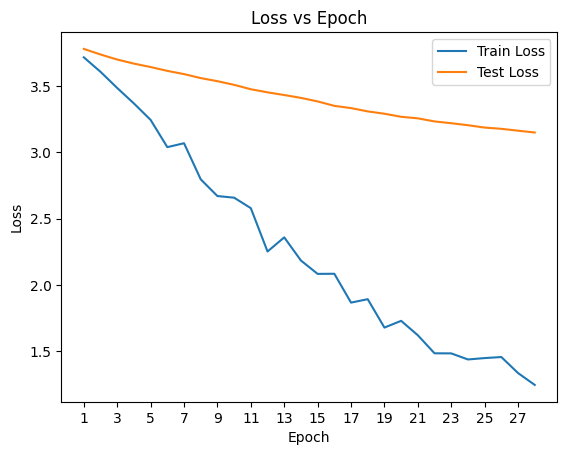

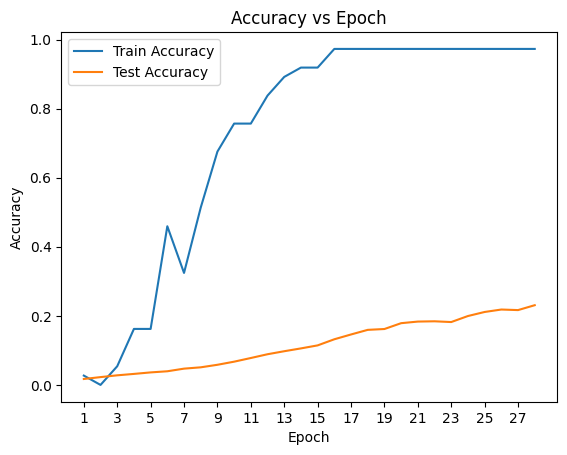


====== SUMMARY TABLE ======
Fraction   S1 l=1     S1 l=2     S1 l=3     S1 l=4     S2 grad   
------------------------------------------------------------
   100%   0.9090    0.9073    0.9103    0.9161    0.9139
    10%   0.7056    0.7348    0.7479    0.7204    0.7615
     1%   0.1575    0.1447    0.1224    0.1251    0.2309


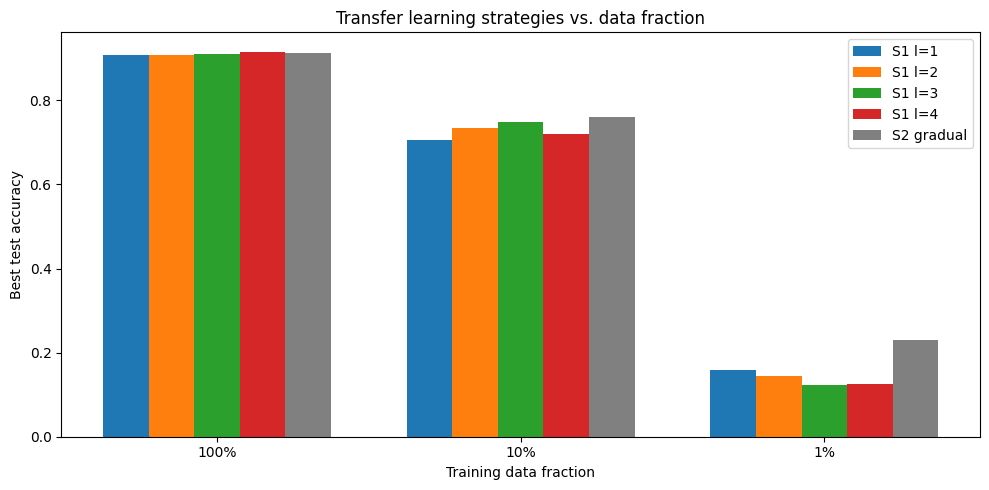

In [8]:
importlib.reload(bp)

FRACTIONS   = [1.0, 0.1, 0.01]
NUM_EPOCHS  = 20
BASE_LR     = 1e-5
strategy1_results = {}
strategy2_results = {}

test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

for frac in FRACTIONS:
    print(f"\n{'='*60}\nFRACTION: {frac*100:.0f}%\n{'='*60}")
    subset      = bp.get_stratified_subset(train_data, frac)
    batch_size  = min(32, max(4, len(subset) // 4))
    num_epochs  = NUM_EPOCHS if frac >= 0.1 else 30
    frac_loader = DataLoader(subset, batch_size=batch_size, shuffle=True, num_workers=2)

    # Strategy 1
    strategy1_results[frac] = {}
    for l in range(1, 5):
        model     = bp.get_model_finetune(num_classes=37).to(device)
        bp.unfreeze_layers(model, l)
        optimizer = bp.get_optimizer(model, l, base_lr=BASE_LR)
        criterion = nn.CrossEntropyLoss()

        print(f"\n-- S1 l={l} | frac={frac} --")
        train_losses, test_losses, train_accs, test_accs, _, best_acc = bp.train_with_history(
            model, frac_loader, test_loader, optimizer, criterion, device, num_epochs=num_epochs
        )
        bp.plot_training_curves(train_losses, test_losses, train_accs, test_accs)
        strategy1_results[frac][l] = best_acc

    # Strategy 2
    model     = bp.get_model_finetune(num_classes=37).to(device)
    criterion = nn.CrossEntropyLoss()
    strategy2_best = 0.0
    all_train_losses, all_test_losses, all_train_accs, all_test_accs = [], [], [], []

    for stage in range(4):
        bp.unfreeze_layers(model, stage + 1)
        optimizer = bp.get_optimizer(model, stage + 1, base_lr=BASE_LR)
        print(f"\n-- S2 stage={stage+1} | frac={frac} --")
        train_losses, test_losses, train_accs, test_accs, _, best_acc = bp.train_with_history(
            model, frac_loader, test_loader, optimizer, criterion, device, num_epochs=num_epochs//4
        )
        all_train_losses += train_losses
        all_test_losses  += test_losses
        all_train_accs   += train_accs
        all_test_accs    += test_accs
        strategy2_best    = max(strategy2_best, best_acc)

    bp.plot_training_curves(all_train_losses, all_test_losses, all_train_accs, all_test_accs)
    strategy2_results[frac] = strategy2_best

bp.print_summary(strategy1_results, strategy2_results, FRACTIONS)
bp.plot_fraction_comparison(strategy1_results, strategy2_results, FRACTIONS)

### Conclusion of experiments using different fractions of the training set

* With enough data (100%), deeper fine tuning performs best (S1) with l=4.
* As labeled data decreases, gradual unfreezing(S2) becomes much more robust.
* For extremely small datasets (1%), S2 significantly outperforms all fixed layer fine tuning strategies.

## L2 regularization